# Project 03 · Seoul Bike Demand AI
## EDA → Feature Engineering → Feature Selection → Model Comparison → Final Model → Research Report


데이터셋: **Seoul Bike Sharing Demand** (`ai-server/data/seoul_bike_data.csv`)

Target: **Rented Bike Count** (시간대별 대여 자전거 수) → Regression(회귀) 문제



```text
EDA
  ↓
Hypothesis (가설 수립)
  ↓
Feature Engineering (파생변수 생성)
  ↓
Feature Selection
  ↓
Train / Test Split
  ↓
Model Comparison (Linear Regression, Decision Tree, Random Forest)
  ↓
Final Model
  ↓
Research Report
```


# Chapter 1. 프로젝트 소개


## Bike Demand Forecasting란?

서울시 공공자전거(따릉이)와 같은 공유 자전거 서비스는 대여소마다 자전거를 미리 배치해
두어야 합니다. 그런데 시간대, 날씨, 계절에 따라 대여 수요가 크게 달라지기 때문에,
"지금 이 시간에 자전거가 몇 대나 필요할까?"를 미리 예측하지 못하면 다음과 같은
문제가 생깁니다.

- 수요가 몰리는 시간대(출퇴근 시간 등)에 자전거가 부족해 고객이 이용하지 못합니다.
- 수요가 적은 시간대/장소에 자전거가 남아돌아 운영 비용(재배치, 보관)이 낭비됩니다.
- 우천/폭설처럼 수요가 급감하는 상황에 대한 대비 없이 자전거를 과다 배치하게 됩니다.

그래서 "다음 시간대에 자전거가 몇 대나 대여될 것인가?"를 미리 예측하는 모델은
자전거 재배치(rebalancing) 운영 계획에 매우 중요하게 사용됩니다.

이 프로젝트는 Chapter 2(고객 이탈 예측)와 달리 정답(Target)이 "이탈했다/안했다"의
두 값이 아니라 **연속적인 숫자(대여 대수)** 이므로, 분류(Classification)가 아니라
**회귀(Regression)** 문제입니다. 평가 지표도 Accuracy/Recall이 아니라
**MAE, RMSE, R²** 를 사용합니다.



## 머신러닝 Workflow


```text
데이터 수집
    ↓
EDA (탐색적 데이터 분석)
    ↓
Hypothesis (가설 수립)
    ↓
Feature Engineering (파생변수 생성)
    ↓
Feature Selection (불필요한 Feature 제거)
    ↓
Train / Test Split
    ↓
Model Comparison (여러 모델 비교)
    ↓
Final Model (최종 모델 선정 및 저장)
```

## Feature Engineering의 목적

원본 컬럼(예: `Temperature`, `Hour`)을 그대로 쓰는 것보다, 컬럼들을 조합하거나
가공해서 **모델이 패턴을 더 쉽게 학습할 수 있는 형태** 로 바꿔주는 작업입니다.

예를 들어 "출퇴근 시간대이면서 동시에 평일인 경우"처럼 두 조건이 겹칠 때만 나타나는
수요 급증 신호는, 원본 컬럼 두 개를 각각 보는 것보다 하나의 파생변수로 만들어주면
모델이 훨씬 더 쉽게 학습합니다.

## Feature Selection의 목적

Feature Engineering으로 파생변수를 만들다 보면, 오히려 서로 비슷한 정보를 담은
중복 Feature가 늘어나거나, Target과 거의 관련이 없는 Feature가 섞이게 됩니다.

Feature Selection은 이렇게 늘어난 Feature 중에서

- 분산이 없어 정보량이 없는 Feature
- 다른 Feature와 거의 동일한 정보를 담은(높은 상관관계) Feature
- 모델이 실제로 중요하게 사용하지 않는 Feature

를 걸러내는 과정입니다.


# Chapter 2. EDA (Exploratory Data Analysis, 탐색적 데이터 분석)


## EDA를 왜 하는가?

EDA를 통해 우리는 다음 질문에 답할 수 있어야 합니다.

- 이 데이터는 몇 시간(Row) 단위로, 몇 개의 정보(컬럼)로 이루어져 있는가?
- 비어있는 값(결측치)은 없는가? 있다면 왜 비어있는가?
- 중복된 시간대 데이터는 없는가?
- Target(Rented Bike Count)은 어떤 분포를 가지는가? 한쪽으로 치우쳐(Skewed) 있지는 않은가?
- 숫자형 변수들은 Target과 어떤 관계가 있는가?
- 범주형 변수(계절, 공휴일, 운영 여부)들은 Target과 어떤 관계가 있는가?
- 시간대(Hour)에 따라 수요는 어떻게 달라지는가?


In [15]:
# ---------------------------------------------------------------
# 라이브러리 불러오기
# ---------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. seaborn 그래프 기본 스타일
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.unicode_minus"] = False

# 2. OS별 한글 폰트 설정
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux, Colab, Ubuntu
    plt.rcParams["font.family"] = "NanumGothic"

# 3. 기타 Matplotlib 설정
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

pd.set_option("display.max_columns", 100)


In [16]:
# ---------------------------------------------------------------
# 데이터 불러오기
# 원본 CSV는 한글 컬럼명이 포함되어 있어 cp949(EUC-KR 계열) 인코딩으로 읽습니다.
# ---------------------------------------------------------------
DATA_PATH = "../data/seoul_bike_data.csv"

df = pd.read_csv(DATA_PATH, encoding="cp949")

# 컬럼명을 서비스(main.py, train_model.py)와 동일한 영문 snake_case로 변경합니다.
df.columns = [
    "date",
    "bike_count",
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day",
]

print("데이터 로드 완료")
print("행(Row) 개수, 열(Column) 개수 :", df.shape)
df.head()


데이터 로드 완료
행(Row) 개수, 열(Column) 개수 : (8760, 14)


,date,bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 2-1. Shape 확인



In [17]:
# (행 개수, 열 개수) 형태의 튜플을 반환합니다.
df.shape

(8760, 14)

## 2-2. info() 확인



In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             8760 non-null   str    
 1   bike_count       8760 non-null   int64  
 2   hour             8760 non-null   int64  
 3   temperature      8760 non-null   float64
 4   humidity         8760 non-null   int64  
 5   wind_speed       8760 non-null   float64
 6   visibility       8760 non-null   int64  
 7   dew_point        8760 non-null   float64
 8   solar_radiation  8760 non-null   float64
 9   rainfall         8760 non-null   float64
 10  snowfall         8760 non-null   float64
 11  season           8760 non-null   str    
 12  holiday          8760 non-null   str    
 13  functioning_day  8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
memory usage: 958.3 KB


## 2-3. 5수 요약(Five-Number Summary)


In [19]:
df.describe()

,bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point,solar_radiation,rainfall,snowfall
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [20]:
# 문자형(범주형) 컬럼의 요약 통계도 함께 확인합니다.
# top: 가장 많이 등장한 값, freq: 그 값이 등장한 횟수
df.describe(include="object")


,date,season,holiday,functioning_day
count,8760,8760,8760,8760
unique,365,4,2,2
top,01/12/2017,Spring,No Holiday,Yes
freq,24,2208,8328,8465


## 2-4. 결측치(Missing Value)


In [21]:
# 컬럼별 결측치 개수 확인
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("결측치가 있는 컬럼:")
print(missing)
print("\n결측치가 있는 컬럼 개수:", len(missing))


결측치가 있는 컬럼:
Series([], dtype: int64)

결측치가 있는 컬럼 개수: 0


## 2-5. 중복 데이터(Duplicate)


In [22]:
# 완전히 동일한 행이 몇 개인지 확인
duplicate_rows = df.duplicated().sum()
print("완전히 중복된 행 개수 :", duplicate_rows)

# Date + Hour 조합 기준 중복 확인 (같은 시간대가 두 번 기록되었는가)
duplicate_datetime = df.duplicated(subset=["date", "hour"]).sum()
print("Date + Hour 조합 중복 개수 :", duplicate_datetime)

print("\n중복 제거 전 데이터 크기 :", df.shape)
df_check = df.drop_duplicates()
print("중복 제거 후 데이터 크기 :", df_check.shape)


완전히 중복된 행 개수 : 0
Date + Hour 조합 중복 개수 : 0

중복 제거 전 데이터 크기 : (8760, 14)
중복 제거 후 데이터 크기 : (8760, 14)


## 2-6. Target 분석 (Rented Bike Count)

이번 프로젝트의 Target은 `bike_count`(시간당 대여 자전거 수)입니다. Chapter 2(고객
이탈)와 달리 Target이 0/1의 두 값이 아니라 연속적인 숫자이므로, `value_counts()`
대신 분포(Histogram)와 기초 통계량으로 분석합니다.


In [23]:
print("bike_count 기초 통계량:")
print(df["bike_count"].describe().round(2))

print("\nbike_count가 0인 시간대 개수:", (df["bike_count"] == 0).sum())
print("bike_count가 0인 비율(%):", round((df["bike_count"] == 0).mean() * 100, 2))


bike_count 기초 통계량:
count    8760.00
mean      704.60
std       645.00
min         0.00
25%       191.00
50%       504.50
75%      1065.25
max      3556.00
Name: bike_count, dtype: float64

bike_count가 0인 시간대 개수: 295
bike_count가 0인 비율(%): 3.37


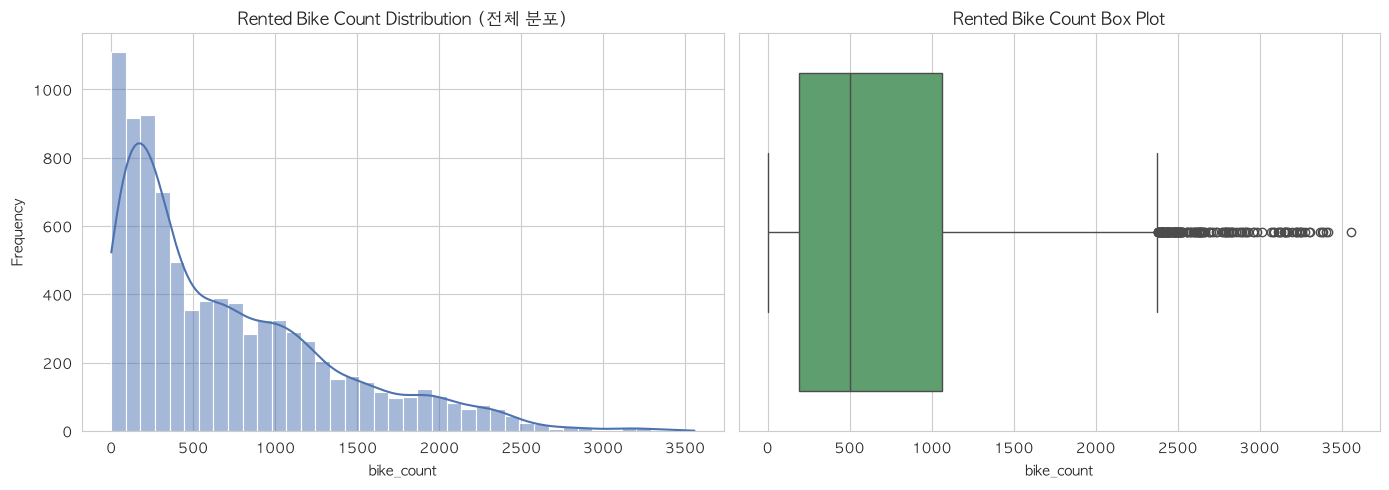

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram: bike_count 분포
sns.histplot(df["bike_count"], bins=40, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Rented Bike Count Distribution (전체 분포)")
axes[0].set_xlabel("bike_count")
axes[0].set_ylabel("Frequency")

# Box Plot: bike_count 이상치 확인
sns.boxplot(x=df["bike_count"], ax=axes[1], color="#55A868")
axes[1].set_title("Rented Bike Count Box Plot")
axes[1].set_xlabel("bike_count")

plt.tight_layout()
plt.show()


## 2-7. 숫자형 변수(Numerical Feature) 분석

각 숫자형 변수에 대해 Histogram(분포), 왜도(Skewness), 첨도(Kurtosis)를 확인합니다.

- **왜도(Skewness)**: 분포가 좌우 대칭인지, 한쪽으로 치우쳐(꼬리가 긴 방향으로) 있는지를
  나타내는 값입니다. 0에 가까울수록 좌우 대칭이고, 양수이면 오른쪽 꼬리가 길고(오른쪽에
  소수의 큰 값), 음수이면 왼쪽 꼬리가 깁니다.
- **첨도(Kurtosis)**: 분포가 얼마나 뾰족한지(중심에 값이 몰려 있는지)를 나타냅니다.
  0에 가까우면 정규분포와 비슷한 뾰족함이고, 음수이면 정규분포보다 완만(납작)합니다.


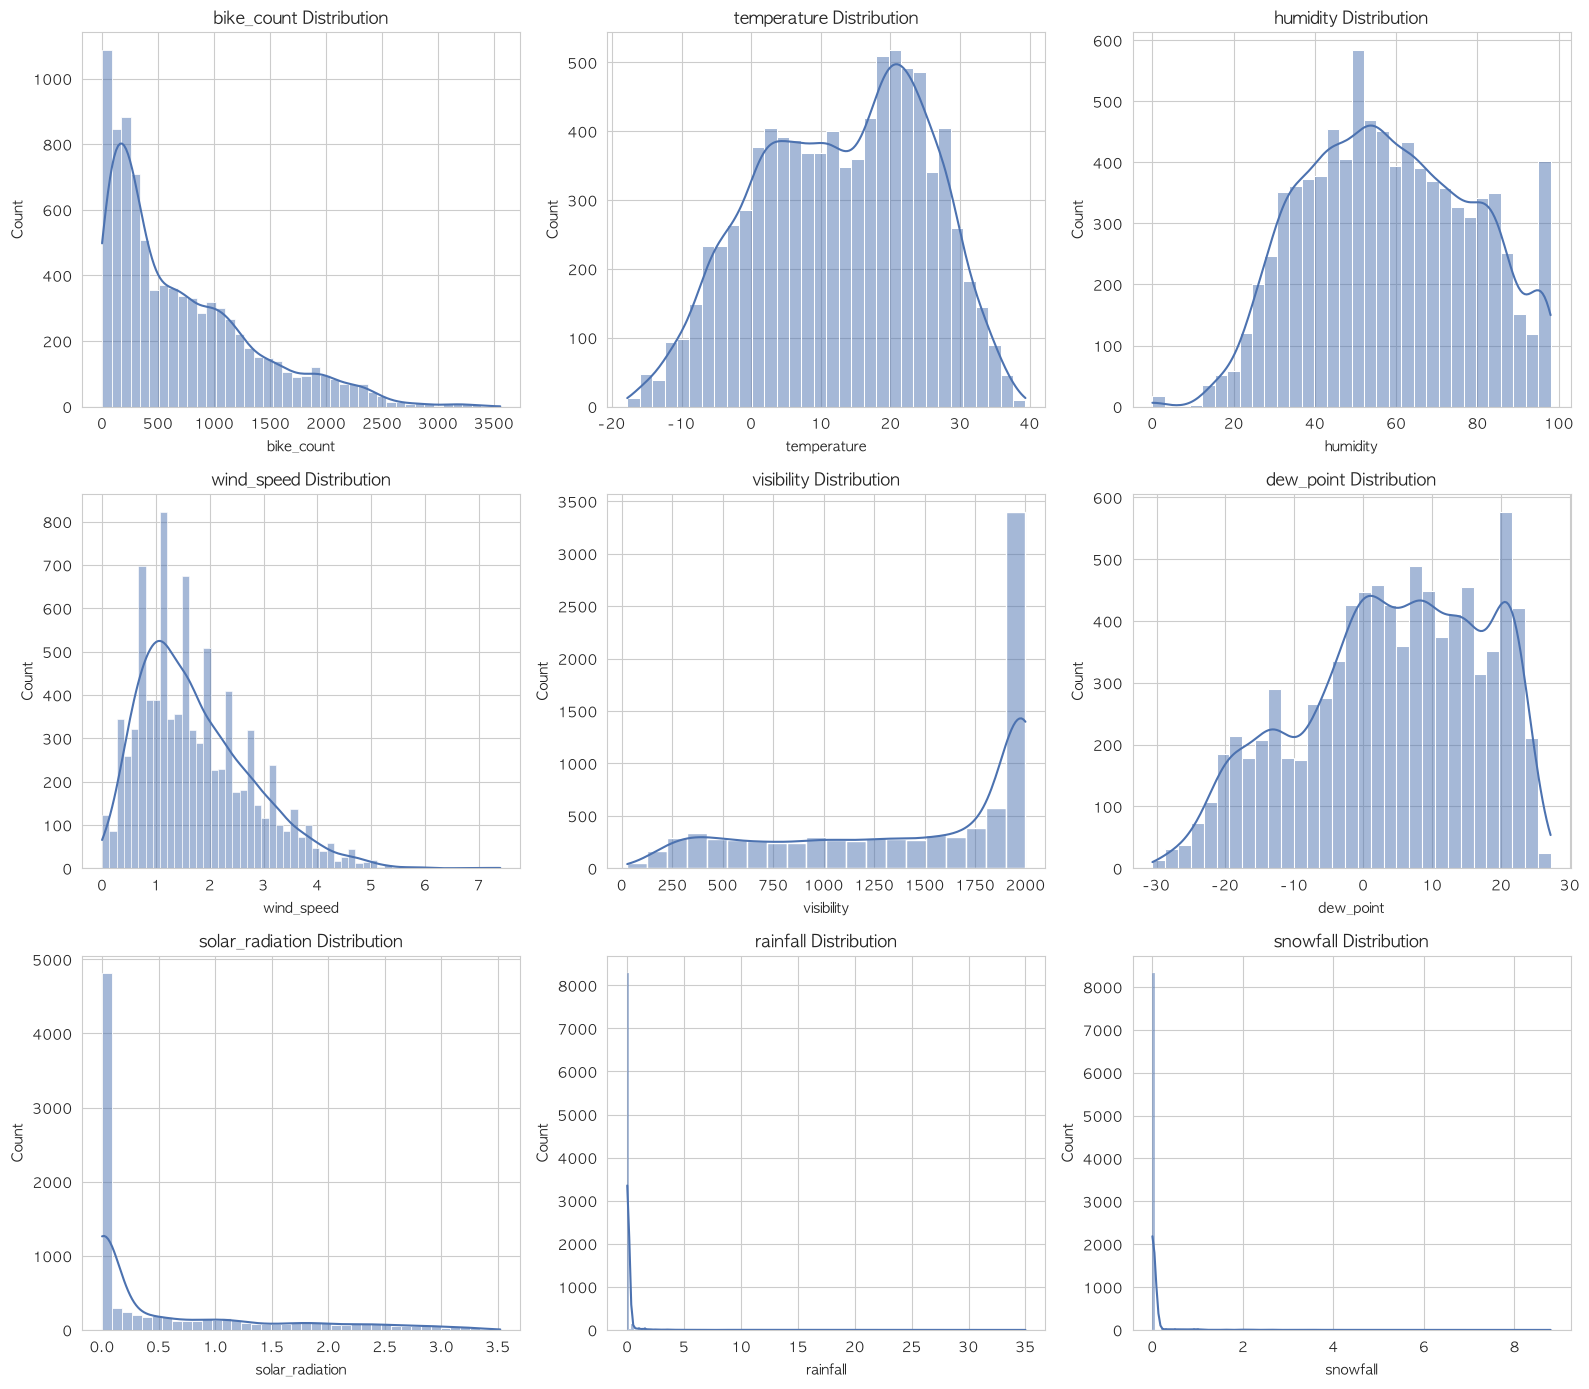

In [26]:
numeric_columns = [
    "bike_count",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point",
    "solar_radiation",
    "rainfall",
    "snowfall",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [27]:
# 왜도(Skewness), 첨도(Kurtosis) 요약표
skew_kurt = pd.DataFrame({
    "mean": df[numeric_columns].mean(),
    "std": df[numeric_columns].std(),
    "skew": df[numeric_columns].skew(),
    "kurtosis": df[numeric_columns].kurt(),
}).round(4)

skew_kurt


,mean,std,skew,kurtosis
bike_count,704.6021,644.9975,1.1534,0.8534
temperature,12.8829,11.9448,-0.1983,-0.8378
humidity,58.2263,20.3624,0.0596,-0.8036
wind_speed,1.7249,1.0363,0.8910,0.7272
visibility,1436.8258,608.2987,-0.7018,-0.9620
dew_point,4.0738,13.0604,-0.3673,-0.7554
solar_radiation,0.5691,0.8687,1.5040,1.1264
rainfall,0.1487,1.1282,14.5332,284.9911
snowfall,0.0751,0.4367,8.4408,93.8033


## 2-8. 범주형 변수(Categorical Feature) 분석

이 데이터셋의 범주형 변수는 `season`(계절), `holiday`(공휴일 여부),
`functioning_day`(운영 여부) 세 가지입니다. 각 변수에 대해 `value_counts()`,
Countplot, 그리고 Target(bike_count 평균)과의 관계를 함께 확인합니다.


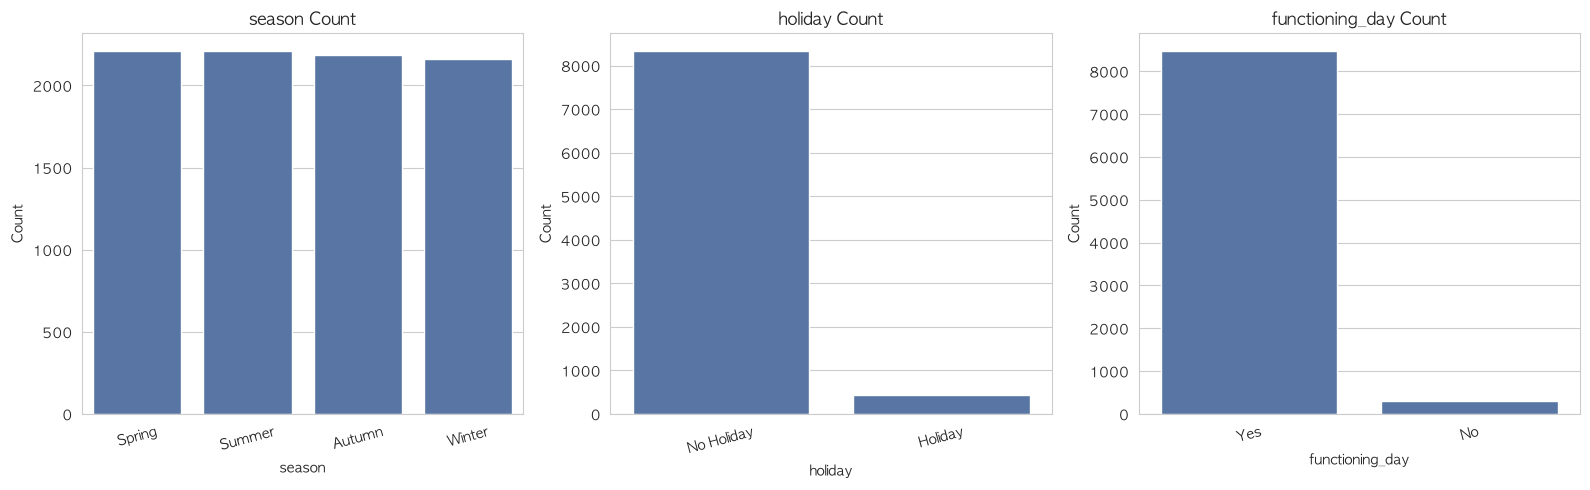

In [28]:
categorical_columns = ["season", "holiday", "functioning_day"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(categorical_columns):
    order = df[col].value_counts().index
    sns.countplot(x=col, data=df, order=order, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} Count")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


In [29]:
# 범주형 변수별 bike_count 평균(수요 평균) 요약
for col in categorical_columns:
    print(f"--- {col} 별 bike_count 평균 ---")
    print(df.groupby(col)["bike_count"].agg(["mean", "count"]).round(1).sort_values("mean", ascending=False))
    print()


--- season 별 bike_count 평균 ---
          mean  count
season               
Summer  1034.1   2208
Autumn   819.6   2184
Spring   730.0   2208
Winter   225.5   2160

--- holiday 별 bike_count 평균 ---
             mean  count
holiday                 
No Holiday  715.2   8328
Holiday     499.8    432

--- functioning_day 별 bike_count 평균 ---
                  mean  count
functioning_day              
Yes              729.2   8465
No                 0.0    295



## 2-9. 시간대(Hour)별 수요 패턴 분석

`hour`는 0~23 사이의 숫자이지만, 시간대에 따라 수요가 오르내리는 패턴 자체가
중요한 정보입니다. 막대그래프보다 **선 그래프(Line Plot)** 로 그리면 하루 동안의
수요 흐름을 더 직관적으로 볼 수 있습니다.


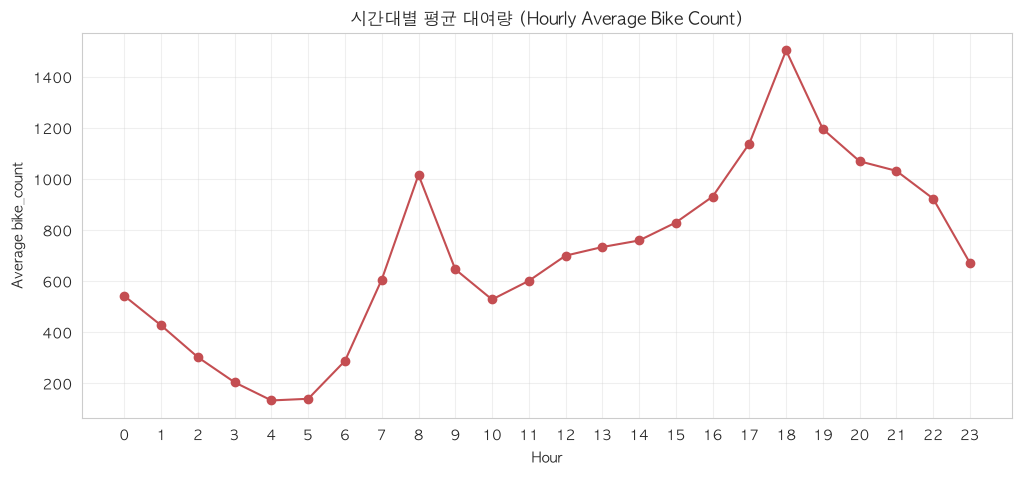

시간대별 평균 대여량:
hour
0      541.5
1      426.2
2      301.6
3      203.3
4      132.6
5      139.1
6      287.6
7      606.0
8     1015.7
9      646.0
10     527.8
11     600.9
12     699.4
13     733.2
14     758.8
15     829.2
16     930.6
17    1138.5
18    1502.9
19    1195.1
20    1069.0
21    1031.4
22     922.8
23     671.1
Name: bike_count, dtype: float64


In [31]:
hourly_mean = df.groupby("hour")["bike_count"].mean()

plt.figure(figsize=(12, 5))
plt.plot(hourly_mean.index, hourly_mean.values, marker="o", color="#C44E52")
plt.title("시간대별 평균 대여량 (Hourly Average Bike Count)")
plt.xlabel("Hour")
plt.ylabel("Average bike_count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.show()

print("시간대별 평균 대여량:")
print(hourly_mean.round(1))


## 2-10. 상관관계(Correlation) 분석

숫자형 변수들 사이의 **피어슨 상관계수(Pearson Correlation Coefficient)** 를 계산합니다.
상관계수는 -1 ~ 1 사이의 값을 가지며,

- **1에 가까울수록** 강한 양의 상관관계 (하나가 커지면 다른 하나도 커짐)
- **-1에 가까울수록** 강한 음의 상관관계 (하나가 커지면 다른 하나는 작아짐)
- **0에 가까울수록** 선형적인 관계가 거의 없음


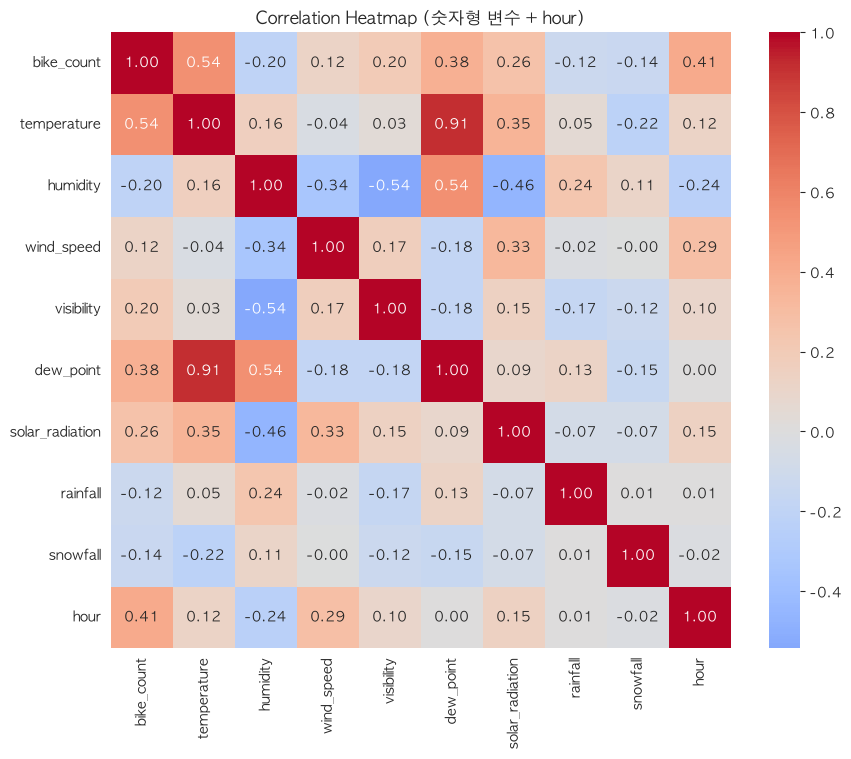

bike_count와의 상관계수 (내림차순):
bike_count         1.0000
temperature        0.5386
hour               0.4103
dew_point          0.3798
solar_radiation    0.2618
visibility         0.1993
wind_speed         0.1211
rainfall          -0.1231
snowfall          -0.1418
humidity          -0.1998
Name: bike_count, dtype: float64


In [32]:
corr_columns = numeric_columns + ["hour"]
corr_matrix = df[corr_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (숫자형 변수 + hour)")
plt.show()

print("bike_count와의 상관계수 (내림차순):")
print(corr_matrix["bike_count"].sort_values(ascending=False).round(4))


## 2-11. Box Plot - 이상치(Outlier) 분석

Box Plot(상자 그림)은 데이터의 분포를 다음 5가지 값으로 요약해서 보여줍니다.

```text
최솟값(이상치 제외) ─ 1사분위수(Q1) ─ 중앙값(Median) ─ 3사분위수(Q3) ─ 최댓값(이상치 제외)
```

Q1과 Q3 사이의 거리를 **IQR(사분위 범위, Interquartile Range)** 이라고 하며,
일반적으로 `Q1 - 1.5*IQR` 보다 작거나 `Q3 + 1.5*IQR` 보다 큰 값을 통계적 이상치로 봅니다.


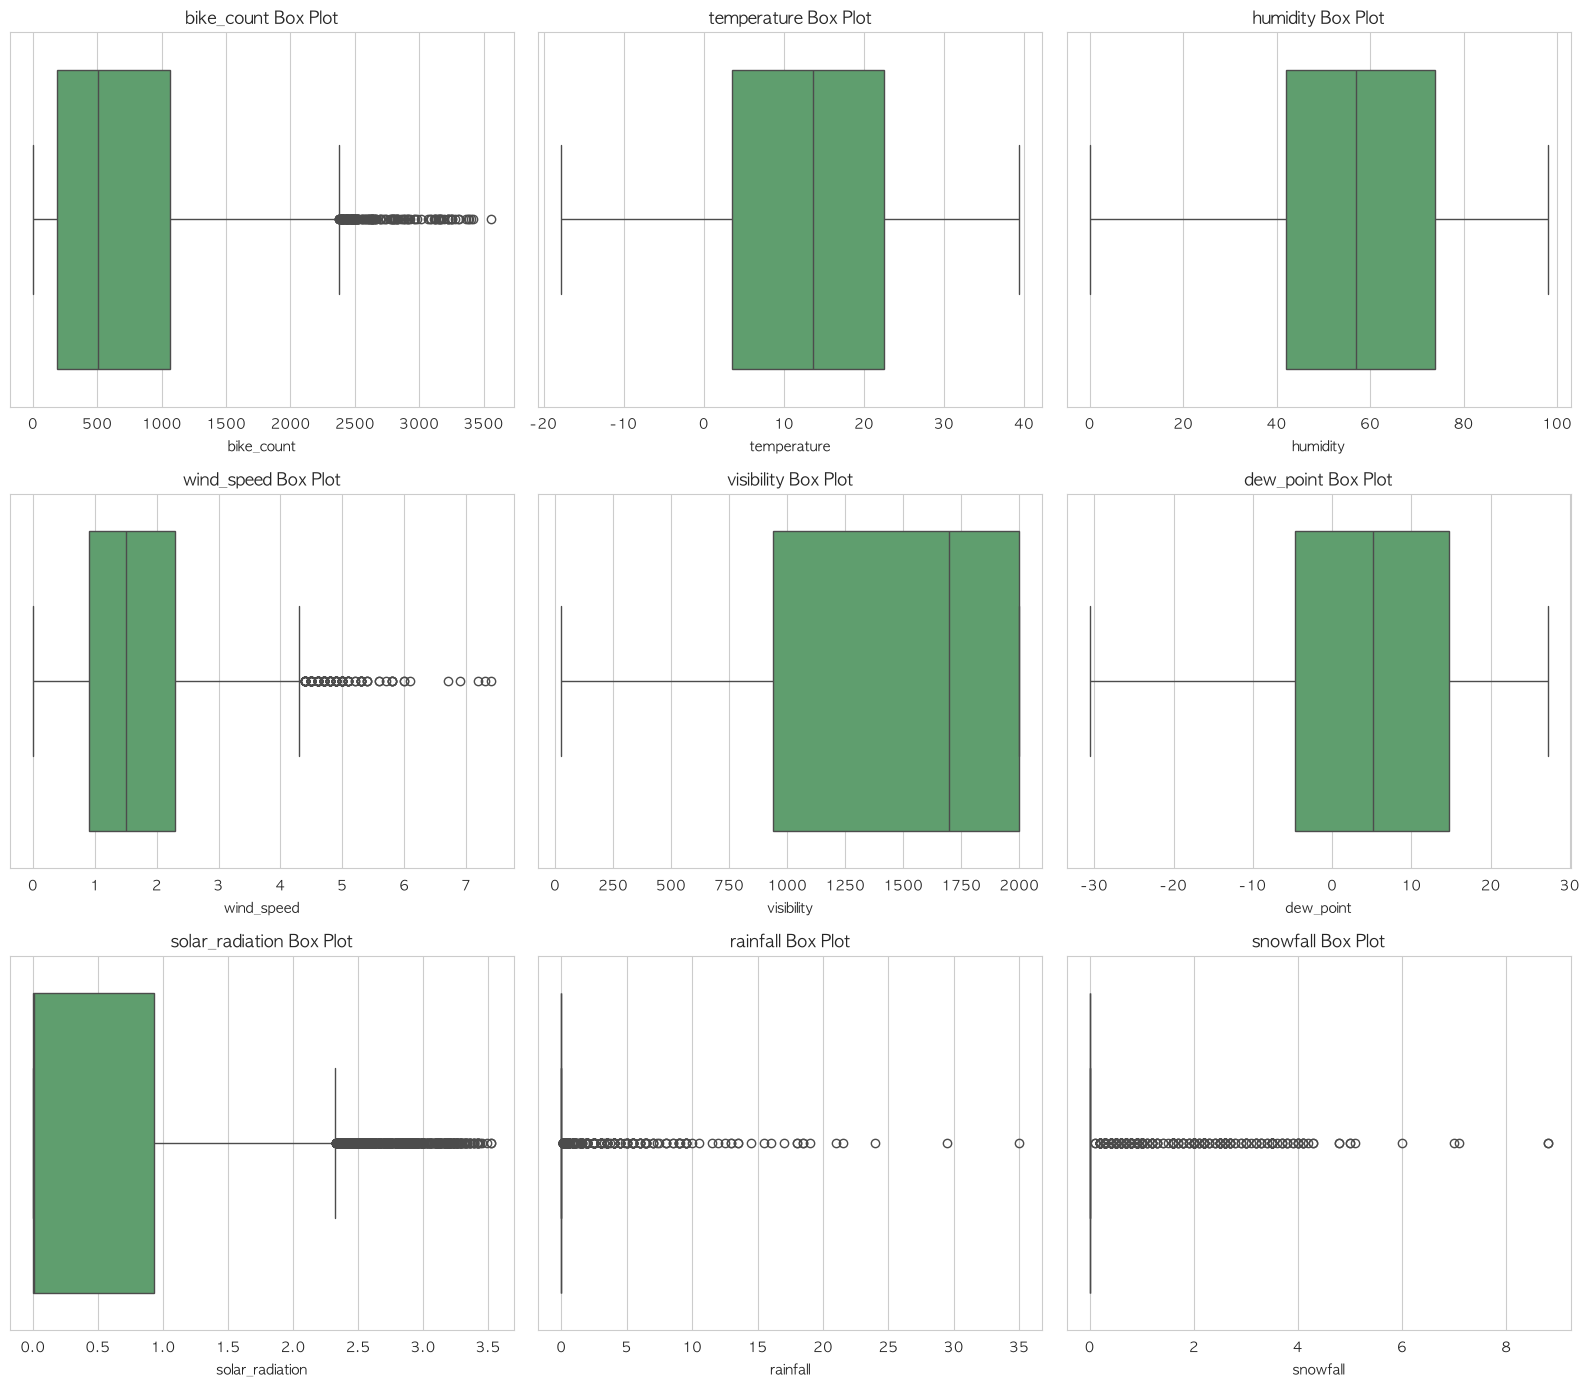

IQR 기준 컬럼별 이상치 개수:
  bike_count : 158건 (1.80%)
  temperature : 0건 (0.00%)
  humidity : 0건 (0.00%)
  wind_speed : 161건 (1.84%)
  visibility : 0건 (0.00%)
  dew_point : 0건 (0.00%)
  solar_radiation : 641건 (7.32%)
  rainfall : 528건 (6.03%)
  snowfall : 443건 (5.06%)


In [33]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

outlier_summary = {}
for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i], color="#55A868")
    axes[i].set_title(f"{col} Box Plot")
    axes[i].set_xlabel(col)

    # IQR 기준 이상치 개수 계산
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = outlier_count

plt.tight_layout()
plt.show()

print("IQR 기준 컬럼별 이상치 개수:")
for col, cnt in outlier_summary.items():
    print(f"  {col} : {cnt}건 ({cnt / len(df) * 100:.2f}%)")


## 2-12. EDA 핵심 발견 사항(EDA Findings)

지금까지의 EDA 결과를 근거와 함께 정리하면 다음과 같습니다. (모든 수치는 위에서 실제로
계산한 결과입니다)

**Finding 1. `functioning_day`가 "No"인 시간대는 대여량이 항상 0이다.**
근거: `functioning_day == "No"`인 295개 시간대의 `bike_count`는 평균/최솟값/최댓값이
모두 0이다.
해석: 운영을 하지 않는 시간대는 당연히 대여가 발생하지 않는다. `functioning_day`는
Target을 사실상 결정짓는 강력한 신호이며, 예측 시점에도 반드시 확보 가능한 값이므로
Feature로 사용할 수 있다.

**Finding 2. 시간대(Hour)에 따라 수요가 뚜렷한 출퇴근 패턴을 보인다.**
근거: 새벽 4시(132.6대)에 가장 적고, 아침 8시(1015.7대)에 1차로 크게 오른 뒤 낮 동안
완만하게 유지되다가, 저녁 18시(1502.9대)에 하루 중 최고치를 기록한다.
해석: 출퇴근 시간대(특히 저녁 퇴근 시간)에 수요가 집중되므로, 이 시간대를 위한 별도의
재배치 전략이 필요하다.

**Finding 3. 기온(Temperature)이 높을수록 대여량이 많다.**
근거: `temperature`와 `bike_count`의 상관계수는 +0.5386으로, 숫자형 변수 중 가장 강하다.
해석: 추운 날씨에는 자전거 이용 자체가 물리적으로 힘들기 때문에, 기온이 수요를 좌우하는
가장 핵심적인 요인이다.

**Finding 4. 계절(Season)에 따라 수요 차이가 매우 크다.**
근거: 여름(Summer) 평균 1034.1대 > 가을(Autumn) 819.6대 > 봄(Spring) 730.0대 >
겨울(Winter) 225.5대로, 여름과 겨울의 차이가 약 4.6배에 달한다.
해석: 겨울철에는 재배치할 자전거 수를 대폭 줄이는 것이 합리적이다.

**Finding 5. 비/눈이 오면 대여량이 급감한다.**
근거: 강수(비 또는 눈)가 있는 시간대의 평균 대여량은 175.6대로, 강수가 없는 시간대의
768.4대에 비해 약 77% 감소한다.
해석: 강수 여부는 기온 다음으로 강력한 수요 억제 요인이다.

**Finding 6. 습도(Humidity)는 대여량과 약한 음의 상관관계를 보인다.**
근거: `humidity`와 `bike_count`의 상관계수는 -0.1998이다.
해석: 습도 자체보다는 기온과 결합되었을 때(불쾌지수 등) 더 의미 있는 신호가 될 수
있다. (Chapter 4에서 직접 검증한다)

**Finding 7. 공휴일(Holiday)에는 평균 대여량이 오히려 더 낮다.**
근거: 공휴일 평균 499.8대 vs 평일(No Holiday) 평균 715.2대.
해석: 이 데이터의 수요는 여가용보다 통근/통학 등 생활형 이용 비중이 크다는 것을
시사한다. 즉 "출퇴근 시간대 + 공휴일이 아님"이 겹치는 시간대가 특히 중요할 수 있다.

**Finding 8. 강수량/적설량은 대부분 0이며, 왜도(Skewness)가 매우 크다.**
근거: `rainfall`의 왜도는 14.53, `snowfall`의 왜도는 8.44로 극단적으로 큰 값이다.
IQR 기준으로는 각각 528건(6.03%), 443건(5.06%)이 "이상치"로 잡히지만, 실제로는
"비/눈이 온 시간대"가 정상적으로 존재하는 것일 뿐 데이터 오류가 아니다.
해석: 강수량/적설량처럼 대부분 0이고 가끔 큰 값이 나오는 변수는 그대로 두거나,
"비가 왔는가(Yes/No)"처럼 이진 신호로 바꾸는 것이 더 유용할 수 있다.

**Finding 9. `bike_count` 자체도 IQR 기준 이상치가 158건(1.80%) 존재한다.**
근거: 대부분 저녁 출퇴근 시간대나 여름철처럼 원래 수요가 높은 시간대에 몰려 있다.
해석: 이 "이상치"는 입력 오류가 아니라 실제로 발생한 고수요 상황이므로 제거하지 않는다.



# Chapter 3. Hypothesis (가설 수립)

**가설 1.** 출퇴근 시간대(아침 7~9시, 저녁 17~20시)는 그 외 시간대보다 대여량이
훨씬 많을 것이다. → EDA Finding 2에서 확인됨 (저녁 18시 1502.9대로 하루 중 최고치)

**가설 2.** 기온이 높을수록 대여량이 늘어날 것이다. → EDA Finding 3에서 확인됨
(상관계수 +0.5386, 숫자형 변수 중 가장 강함)

**가설 3.** 비/눈이 오면 대여량이 급격히 줄어들 것이다. → EDA Finding 5에서 확인됨
(강수 175.6대 vs 무강수 768.4대)

**가설 4.** 기온과 습도를 함께 고려한 "체감 불쾌지수"가 기온 하나만 보는 것보다 더
유용한 신호일 것이다. → Chapter 4에서 직접 검증한다.

**가설 5.** 공휴일이 아니면서 동시에 출퇴근 시간대인 경우, "순수한 통근 수요"가
겹쳐서 대여량이 가장 높게 나타날 것이다. → EDA Finding 7(공휴일에 오히려 대여량이
낮음)을 근거로 Chapter 4에서 직접 검증한다.

**가설 6.** 시야(Visibility)가 낮거나 바람이 강한 등 여러 악천후 조건이 동시에
겹치면, 개별 조건 하나만 나쁠 때보다 대여량이 훨씬 더 크게 줄어들 것이다.
→ Chapter 4에서 직접 검증한다.

**가설 7.** 기온과 이슬점(Dew Point)의 차이가 클수록(공기가 건조할수록) 자전거를
타기 쾌적한 조건일 것이므로 대여량과 관련이 있을 것이다. → Chapter 4에서 직접
검증한다.


이제 이 가설들을 실제 파생변수(Feature)로 만드는 **Feature Engineering** 을 시작합니다.



# Chapter 4. Feature Engineering (파생변수 생성)


Feature Engineering은 원본 컬럼을 조합하거나 가공하여, 모델이 패턴을 더 쉽게 학습할 수
있는 새로운 입력값을 만드는 과정입니다. 이번 Chapter에서는 아래 8개의 파생변수를
만듭니다. 각 파생변수는 Chapter 2(EDA)와 Chapter 3(가설)에서 확인한 근거를 바탕으로
설계되었습니다.

```text
1. IsRushHour            - 출퇴근 시간대 여부
2. HourBlock             - 시간대 구간화 (새벽/오전/오후/저녁)
3. TemperatureBin        - 기온 구간화
4. IsPrecipitation       - 강수(비 또는 눈) 여부
5. DiscomfortIndex       - 기온 + 습도 기반 불쾌지수
6. IsCommuteTime         - 출퇴근 시간대 + 평일(공휴일 아님) 결합
7. WeatherSeverityScore  - 여러 악천후 조건 결합 점수
8. DewPointGap           - 기온과 이슬점의 차이
```

파생변수를 만들 때는 다음 원칙을 지킵니다.

```text
1. 비즈니스 의미가 있어야 한다.
2. 원본 변수보다 이해하기 쉬운 정보를 제공해야 한다.
3. 예측 시점(자전거 대여를 예측하는 시점)에 계산할 수 있어야 한다.
4. Target(bike_count)을 직접 사용하지 않는다.
5. 데이터 누수(Data Leakage)가 없어야 한다.
```

> **참고**: 실제 서비스 API(`main.py`)는 `hour, temperature, humidity, wind_speed,
> visibility, dew_point, solar_radiation, rainfall, snowfall, season, holiday,
> functioning_day` 만 입력으로 받고 **날짜(요일) 정보는 받지 않습니다.** 따라서 "주말
> 여부"처럼 날짜가 있어야 계산할 수 있는 Feature는 원칙 3(예측 시점에 계산 가능해야
> 한다)에 위배되므로 이번 Feature Engineering에서는 사용하지 않습니다.

## 성능 비교를 위한 준비

각 Feature를 만들 때마다 "이 Feature를 추가하기 전 vs 추가한 후" 모델 성능을 비교합니다.
분류 문제와 달리 이번에는 회귀 문제이므로 **MAE(평균절대오차), RMSE(평균제곱근오차),
R²(결정계수)** 로 성능을 비교합니다. MAE, RMSE는 작을수록, R²는 1에 가까울수록 좋은
모델입니다.


In [34]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

# Target, 날짜(요일 정보라 예측 시점에 사용 불가)는 Feature 실험에서 제외합니다.
LEAKAGE_OR_ID_COLUMNS = ["date", "bike_count"]

BASELINE_COLUMNS = [c for c in df.columns if c not in LEAKAGE_OR_ID_COLUMNS]

print(f"Baseline Feature 개수: {len(BASELINE_COLUMNS)}")
print(BASELINE_COLUMNS)


def quick_evaluate(frame, feature_cols, label):
    """주어진 Feature 목록으로 RandomForest Regressor를 빠르게 학습하고 성능을 반환한다.
    (Feature Engineering 실습용 - Chapter 6의 공식 Pipeline과는 별개)
    """
    X = pd.get_dummies(frame[feature_cols], drop_first=False)
    y = frame["bike_count"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    return {
        "Model": label,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(mean_squared_error(y_test, pred) ** 0.5, 2),
        "R2": round(r2_score(y_test, pred), 4),
    }


baseline_result = quick_evaluate(df, BASELINE_COLUMNS, "Baseline (원본 Feature)")
feature_experiment_results = [baseline_result]
pd.DataFrame(feature_experiment_results)


Baseline Feature 개수: 12
['hour', 'temperature', 'humidity', 'wind_speed', 'visibility', 'dew_point', 'solar_radiation', 'rainfall', 'snowfall', 'season', 'holiday', 'functioning_day']


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603


## Feature 1. IsRushHour (출퇴근 시간대 여부)

`hour`는 0~23 사이의 연속된 숫자입니다. EDA(2-9, Finding 2)에서 확인했듯, 대여량은
"숫자가 커질수록 일정하게 늘어나는" 단순한 선형 관계가 아니라 새벽에 낮고 아침/저녁에
크게 솟아오르는 복잡한 패턴을 보입니다. 이 중 아침(7~8시)과 저녁(17~20시) 구간을
"출퇴근 시간대"로 명확하게 표시합니다.

### 생성 이유
가설 1을 직접 검증하고, 출퇴근이라는 "명시적인 신호"를 모델에 제공합니다.


In [35]:
# 출퇴근 시간대(아침 7-8시, 저녁 17-20시)를 1, 그 외 시간대를 0으로 표시합니다.
df["IsRushHour"] = df["hour"].isin([7, 8, 17, 18, 19, 20]).astype(int)

rush_hour_effect = df.groupby("IsRushHour")["bike_count"].agg(["mean", "count"]).round(1)
rush_hour_effect


,mean,count
IsRushHour,,
0,576.8,6570
1,1087.9,2190


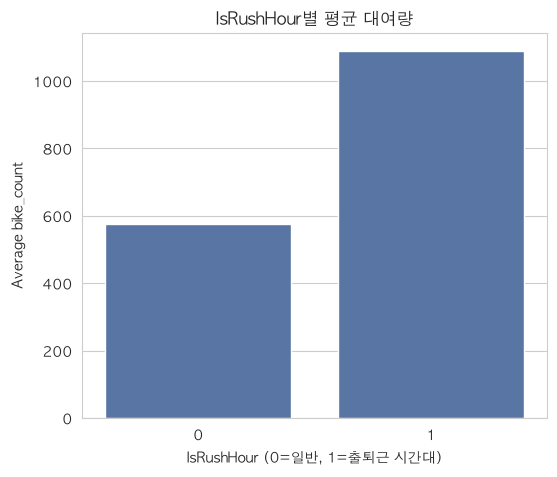

In [36]:
plt.figure(figsize=(6, 5))
sns.barplot(x=rush_hour_effect.index, y=rush_hour_effect["mean"], color="#4C72B0")
plt.title("IsRushHour별 평균 대여량")
plt.xlabel("IsRushHour (0=일반, 1=출퇴근 시간대)")
plt.ylabel("Average bike_count")
plt.show()


In [37]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["IsRushHour"], "Baseline + IsRushHour")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583


> **모델에 따라 Feature의 가치가 다르게 나타날 수 있습니다.**
>
> 위 결과에서 RandomForest는 `IsRushHour`를 추가해도 성능이 거의 개선되지 않습니다
> (트리 기반 모델은 `hour` 원본 값만으로도 이미 출퇴근 패턴을 스스로 찾아낼 수 있기
> 때문입니다). 하지만 아래처럼 **Linear Regression** 으로 같은 실험을 해보면 이야기가
> 달라집니다. Linear Regression은 `hour`와 `bike_count`의 관계를 "직선"으로만
> 가정하기 때문에, 새벽-아침-저녁으로 오르내리는 비선형 패턴을 스스로 찾아내지
> 못합니다. 이럴 때는 `IsRushHour`처럼 사람이 직접 패턴을 알려주는 Feature가 훨씬
> 큰 도움이 됩니다. (R² 0.5337 → 0.6070로 상승, RandomForest보다 훨씬 큰 개선폭)
>
> 즉, "이 Feature가 좋은가?"는 어떤 모델을 쓰느냐에 따라 달라질 수 있습니다.


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


def quick_evaluate_linear(frame, feature_cols, label):
    """Linear Regression 기준으로 같은 Feature의 효과를 비교해본다. (참고용)"""
    X = pd.get_dummies(frame[feature_cols], drop_first=False)
    y = frame["bike_count"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)

    return {
        "Model": label,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(mean_squared_error(y_test, pred) ** 0.5, 2),
        "R2": round(r2_score(y_test, pred), 4),
    }


linear_comparison = [
    quick_evaluate_linear(df, BASELINE_COLUMNS, "Linear Regression Baseline"),
    quick_evaluate_linear(df, BASELINE_COLUMNS + ["IsRushHour"], "Linear Regression Baseline + IsRushHour"),
]
pd.DataFrame(linear_comparison)


,Model,MAE,RMSE,R2
0,Linear Regression Baseline,330.39,440.78,0.5337
1,Linear Regression Baseline + IsRushHour,308.43,404.64,0.6070


## Feature 2. HourBlock (시간대 구간화)

`IsRushHour`가 "출퇴근이냐 아니냐"의 2가지로만 나눈다면, `HourBlock`은 하루를
새벽/오전/오후/저녁 4개 구간으로 더 세분화합니다.

### 생성 이유
2-9에서 확인한 시간대별 수요 곡선은 4개의 뚜렷한 구간(새벽에 낮음, 오전에 상승,
오후에 유지, 저녁에 최고)으로 나눌 수 있습니다. 이 구간 정보를 범주형 변수로
명확하게 표현합니다.


In [39]:
hour_bins = [-1, 5, 11, 17, 23]
hour_labels = ["Dawn(0-5)", "Morning(6-11)", "Afternoon(12-17)", "Evening(18-23)"]

df["HourBlock"] = pd.cut(df["hour"], bins=hour_bins, labels=hour_labels)

hour_block_effect = df.groupby("HourBlock", observed=True)["bike_count"].agg(["mean", "count"]).round(1)
hour_block_effect


,mean,count
HourBlock,,
Dawn(0-5),290.7,2190
Morning(6-11),614.0,2190
Afternoon(12-17),848.3,2190
Evening(18-23),1065.4,2190


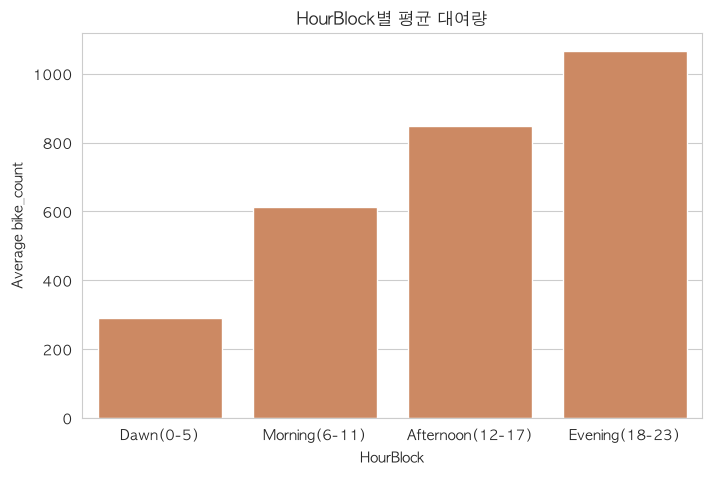

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(x=hour_block_effect.index, y=hour_block_effect["mean"], color="#DD8452")
plt.title("HourBlock별 평균 대여량")
plt.xlabel("HourBlock")
plt.ylabel("Average bike_count")
plt.show()


In [41]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["HourBlock"], "Baseline + HourBlock")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610


## Feature 3. TemperatureBin (기온 구간화)

연속형 변수를 특정 구간으로 나누는 `cut()`을 다시 한 번 연습합니다. 이번에는 기온을
5개 구간(영하/한랭/온화/따뜻/더움)으로 나눕니다.

### 생성 이유
가설 2에서 확인했듯 기온은 대여량과 가장 강한 상관관계(+0.5386)를 가집니다. 다만
Chapter 2-11 이상치 분석처럼, 너무 더운 날에는 오히려 증가세가 둔화될 수 있습니다.
구간화하면 이런 비선형적인 "천장 효과(ceiling effect)"를 모델이 더 쉽게 학습할 수
있습니다.


In [42]:
temp_bins = [-20, 0, 10, 20, 30, 40]
temp_labels = ["Freezing(~0)", "Cold(0-10)", "Mild(10-20)", "Warm(20-30)", "Hot(30+)"]

df["TemperatureBin"] = pd.cut(df["temperature"], bins=temp_bins, labels=temp_labels)

temp_bin_effect = df.groupby("TemperatureBin", observed=True)["bike_count"].agg(["mean", "count"]).round(1)
temp_bin_effect


,mean,count
TemperatureBin,,
Freezing(~0),199.5,1454
Cold(0-10),424.7,2143
Mild(10-20),765.1,2264
Warm(20-30),1120.0,2387
Hot(30+),1106.4,512


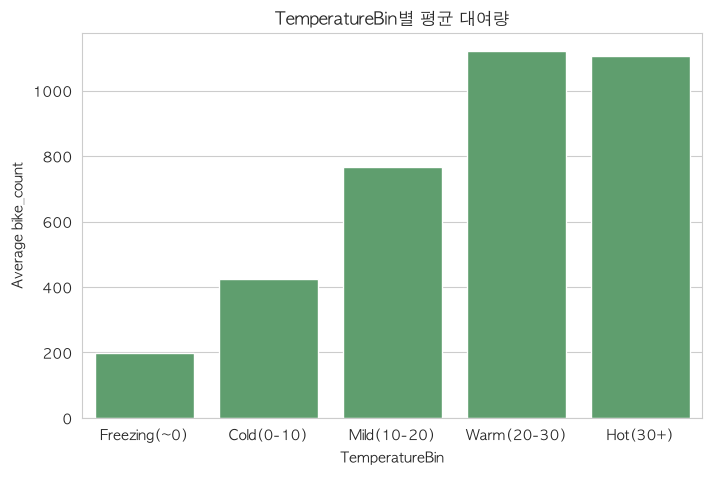

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(x=temp_bin_effect.index, y=temp_bin_effect["mean"], color="#55A868")
plt.title("TemperatureBin별 평균 대여량")
plt.xlabel("TemperatureBin")
plt.ylabel("Average bike_count")
plt.show()


In [44]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["TemperatureBin"], "Baseline + TemperatureBin")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605


위 표를 보면 `Warm(20-30)` 구간(1120.0대)이 `Hot(30+)` 구간(1106.4대)보다 오히려
평균 대여량이 살짝 더 높습니다. 즉 기온이 계속 오른다고 대여량이 무한정 늘어나는
것이 아니라, 특정 구간을 넘어서면 증가세가 꺾이는 **비선형 천장 효과**가 실제
데이터에서도 확인됩니다.


## Feature 4. IsPrecipitation (강수 여부)

`rainfall`, `snowfall`은 대부분 0이고 가끔 큰 값이 나오는(Finding 8) 극단적으로
치우친 변수입니다. 두 컬럼을 하나로 합쳐 "비 또는 눈이 왔는가(Yes/No)"라는 훨씬
단순하고 강한 이진 신호로 바꿉니다.

### 생성 이유
가설 3(비/눈이 오면 대여량이 급감한다)을 직접 검증하고, 왜도가 큰 두 컬럼을
다루기 쉬운 형태로 정리합니다.


In [45]:
# rainfall 또는 snowfall이 0보다 크면 강수가 있었던 것으로 표시합니다.
df["IsPrecipitation"] = ((df["rainfall"] > 0) | (df["snowfall"] > 0)).astype(int)

precipitation_effect = df.groupby("IsPrecipitation")["bike_count"].agg(["mean", "count"]).round(1)
precipitation_effect


,mean,count
IsPrecipitation,,
0,768.4,7817
1,175.6,943


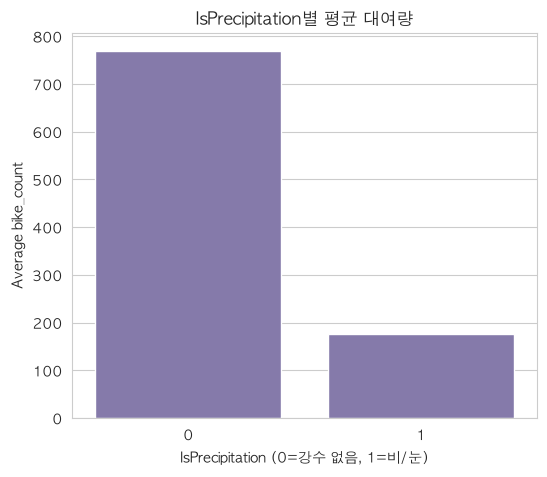

In [46]:
plt.figure(figsize=(6, 5))
sns.barplot(x=precipitation_effect.index, y=precipitation_effect["mean"], color="#8172B2")
plt.title("IsPrecipitation별 평균 대여량")
plt.xlabel("IsPrecipitation (0=강수 없음, 1=비/눈)")
plt.ylabel("Average bike_count")
plt.show()


In [32]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["IsPrecipitation"], "Baseline + IsPrecipitation")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605
4,Baseline + IsPrecipitation,144.92,240.88,0.8607


## Feature 5. DiscomfortIndex (불쾌지수)

기상청에서 실제로 사용하는 **불쾌지수(Discomfort Index)** 공식을 이용해 기온과
습도를 하나의 지표로 결합합니다.

```text
DiscomfortIndex = 0.81 * 기온 + 0.01 * 습도 * (0.99 * 기온 - 14.3) + 46.3
```

### 생성 이유
가설 4를 직접 검증합니다. 기온만 볼 때보다 "체감 쾌적함"을 더 잘 반영할 것이라는
가설을 세웠습니다.


In [47]:
df["DiscomfortIndex"] = (
    0.81 * df["temperature"]
    + 0.01 * df["humidity"] * (0.99 * df["temperature"] - 14.3)
    + 46.3
)

print("DiscomfortIndex와 bike_count의 상관계수:", round(df["DiscomfortIndex"].corr(df["bike_count"]), 4))
print("temperature와 bike_count의 상관계수      :", round(df["temperature"].corr(df["bike_count"]), 4))
print("DiscomfortIndex와 temperature의 상관계수  :", round(df["DiscomfortIndex"].corr(df["temperature"]), 4))
df[["temperature", "humidity", "DiscomfortIndex"]].describe().round(2)


DiscomfortIndex와 bike_count의 상관계수: 0.5273
temperature와 bike_count의 상관계수      : 0.5386
DiscomfortIndex와 temperature의 상관계수  : 0.9909


,temperature,humidity,DiscomfortIndex
count,8760.00,8760.00,8760.00
mean,12.88,58.23,56.22
std,11.94,20.36,15.99
min,-17.80,0.00,16.00
25%,3.50,42.00,43.25
50%,13.70,57.00,57.03
75%,22.50,74.00,69.56
max,39.40,98.00,87.86


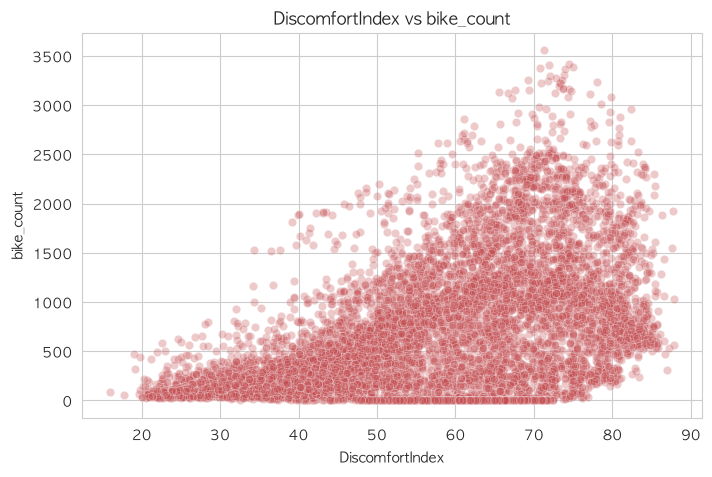

In [48]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="DiscomfortIndex", y="bike_count", data=df, alpha=0.3, color="#C44E52")
plt.title("DiscomfortIndex vs bike_count")
plt.xlabel("DiscomfortIndex")
plt.ylabel("bike_count")
plt.show()


In [49]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["DiscomfortIndex"], "Baseline + DiscomfortIndex")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605
4,Baseline + DiscomfortIndex,143.12,237.27,0.8649


`DiscomfortIndex`는 지금까지 만든 Feature 중 RandomForest 성능을 가장 크게
끌어올렸습니다. 다만 `temperature`와의 상관계수가 0.99에 달할 정도로 매우 높아서,
두 정보가 상당 부분 겹친다는 점은 Chapter 5(Feature Selection)에서 다시 검토합니다.


## Feature 6. IsCommuteTime (출퇴근 시간대 + 평일 결합)

`IsRushHour`(시간대)와 `holiday`(공휴일 여부)를 AND 조건으로 결합한 상호작용
Feature입니다.

### 이론
Finding 7에서 공휴일 평균 대여량(499.8대)이 평일(715.2대)보다 오히려 낮다는 것을
확인했습니다. 이는 이 데이터의 수요가 여가보다 통근 성격이 강하다는 뜻입니다. 그렇다면
"출퇴근 시간대이면서 동시에 공휴일이 아닌" 시간대는 순수한 통근 수요가 겹쳐서 대여량이
가장 높게 나타날 것입니다.

### 생성 이유
가설 5를 직접 검증합니다.


In [50]:
df["IsCommuteTime"] = ((df["IsRushHour"] == 1) & (df["holiday"] == "No Holiday")).astype(int)

commute_effect = df.groupby("IsCommuteTime")["bike_count"].agg(["mean", "count"]).round(1)
commute_effect


,mean,count
IsCommuteTime,,
0,577.3,6678
1,1112.9,2082


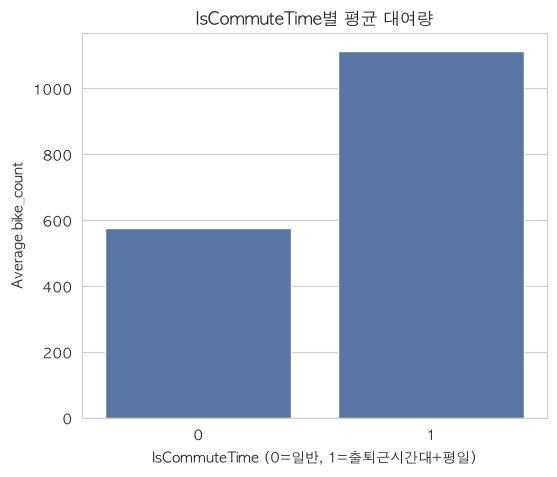

In [51]:
plt.figure(figsize=(6, 5))
sns.barplot(x=commute_effect.index, y=commute_effect["mean"], color="#4C72B0")
plt.title("IsCommuteTime별 평균 대여량")
plt.xlabel("IsCommuteTime (0=일반, 1=출퇴근시간대+평일)")
plt.ylabel("Average bike_count")
plt.show()


In [52]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["IsRushHour", "IsCommuteTime"], "Baseline + IsRushHour + IsCommuteTime")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605
4,Baseline + DiscomfortIndex,143.12,237.27,0.8649
5,Baseline + IsRushHour + IsCommuteTime,145.34,239.58,0.8622


## Feature 7. WeatherSeverityScore (다중 악천후 조건 결합 Feature)

가설 6을 검증합니다. 강수 여부, 낮은 시야, 강한 바람이라는 3가지 "악천후 신호"가
동시에 겹치는 시간대는 정말로 더 위험(수요 급감)할까요? 각 조건을 0/1로 표시한 뒤
더해서 0~3점 사이의 점수를 만듭니다.

### 생성 이유
개별 악천후 신호를 각각 넣는 것보다, "악천후 조건이 몇 개나 겹치는가"를 하나의
점수로 표현하면 모델이 복합적인 악천후 상황을 더 쉽게 학습할 수 있습니다.


In [53]:
# 시야는 하위 25%, 바람은 상위 25%를 기준으로 "나쁨"을 판단합니다.
visibility_threshold = df["visibility"].quantile(0.25)
wind_speed_threshold = df["wind_speed"].quantile(0.75)

df["IsLowVisibility"] = (df["visibility"] < visibility_threshold).astype(int)
df["IsStrongWind"] = (df["wind_speed"] > wind_speed_threshold).astype(int)

df["WeatherSeverityScore"] = df["IsPrecipitation"] + df["IsLowVisibility"] + df["IsStrongWind"]

severity_effect = df.groupby("WeatherSeverityScore")["bike_count"].agg(["mean", "count"]).round(1)
severity_effect


,mean,count
WeatherSeverityScore,,
0,778.0,4484
1,713.5,3327
2,345.0,874
3,114.0,75


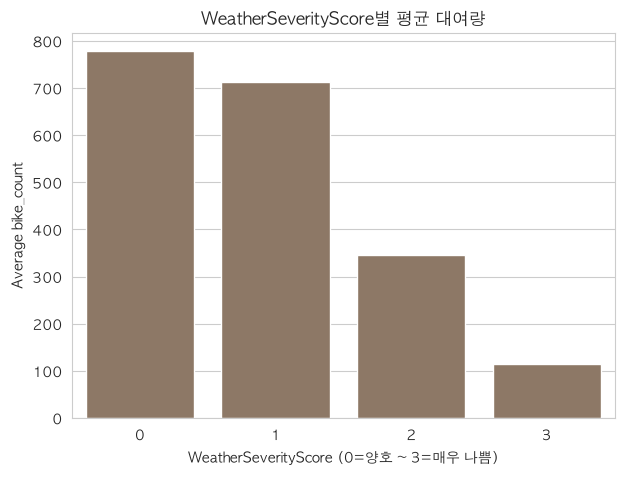

In [54]:
plt.figure(figsize=(7, 5))
sns.barplot(x=severity_effect.index, y=severity_effect["mean"], color="#937860")
plt.title("WeatherSeverityScore별 평균 대여량")
plt.xlabel("WeatherSeverityScore (0=양호 ~ 3=매우 나쁨)")
plt.ylabel("Average bike_count")
plt.show()


In [55]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["WeatherSeverityScore"], "Baseline + WeatherSeverityScore")
feature_experiment_results.append(result)
pd.DataFrame(feature_experiment_results)


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605
4,Baseline + DiscomfortIndex,143.12,237.27,0.8649
5,Baseline + IsRushHour + IsCommuteTime,145.34,239.58,0.8622
6,Baseline + WeatherSeverityScore,145.31,241.45,0.8601


## Feature 8. DewPointGap (기온-이슬점 차이)

두 컬럼을 빼서 새로운 차이(Gap) Feature를 만드는 방법을 익힙니다.

### 이론
이슬점(Dew Point)은 공기 중 수증기가 응결되기 시작하는 온도로, 기온과 이슬점의
차이가 작을수록 공기가 습하고 답답하게 느껴집니다. 반대로 차이가 클수록 공기가
건조하고 쾌적합니다.

### 생성 이유
가설 7을 직접 검증합니다.


In [56]:
df["DewPointGap"] = df["temperature"] - df["dew_point"]

print("DewPointGap과 bike_count의 상관계수:", round(df["DewPointGap"].corr(df["bike_count"]), 4))
print("DewPointGap과 humidity의 상관계수  :", round(df["DewPointGap"].corr(df["humidity"]), 4))
df[["temperature", "dew_point", "DewPointGap"]].describe().round(2)


DewPointGap과 bike_count의 상관계수: 0.2761
DewPointGap과 humidity의 상관계수  : -0.9577


,temperature,dew_point,DewPointGap
count,8760.00,8760.00,8760.00
mean,12.88,4.07,8.81
std,11.94,13.06,5.33
min,-17.80,-30.60,0.40
25%,3.50,-4.70,4.60
50%,13.70,5.10,8.20
75%,22.50,14.80,12.32
max,39.40,27.20,33.60


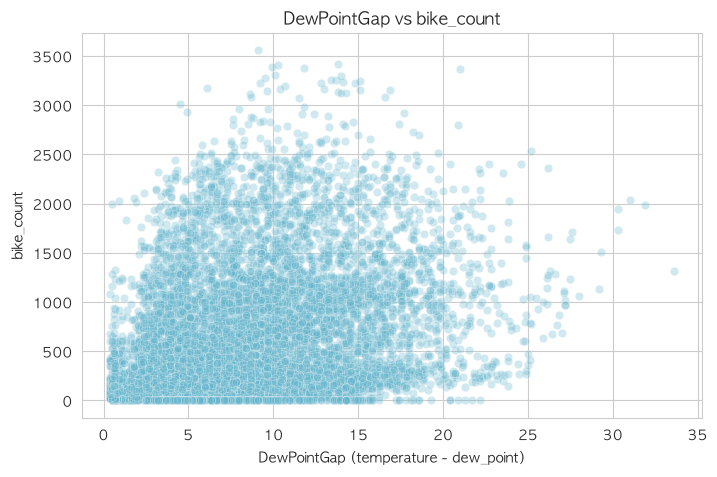

In [57]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="DewPointGap", y="bike_count", data=df, alpha=0.3, color="#64B5CD")
plt.title("DewPointGap vs bike_count")
plt.xlabel("DewPointGap (temperature - dew_point)")
plt.ylabel("bike_count")
plt.show()


In [58]:
result = quick_evaluate(df, BASELINE_COLUMNS + ["DewPointGap"], "Baseline + DewPointGap")
feature_experiment_results.append(result)
feature_experiment_df = pd.DataFrame(feature_experiment_results)
feature_experiment_df


,Model,MAE,RMSE,R2
0,Baseline (원본 Feature),145.18,241.29,0.8603
1,Baseline + IsRushHour,147.11,242.97,0.8583
2,Baseline + HourBlock,144.98,240.61,0.8610
3,Baseline + TemperatureBin,145.26,241.11,0.8605
4,Baseline + DiscomfortIndex,143.12,237.27,0.8649
5,Baseline + IsRushHour + IsCommuteTime,145.34,239.58,0.8622
6,Baseline + WeatherSeverityScore,145.31,241.45,0.8601
7,Baseline + DewPointGap,145.11,241.08,0.8605


`DewPointGap`은 `humidity`와 상관계수가 -0.9577에 달할 정도로 습도와 거의 반대
방향으로 겹치는 정보입니다. 이 역시 Chapter 5(Feature Selection)의 상관관계 분석에서
다시 확인합니다.

지금까지의 실험 결과를 종합하면, RandomForest처럼 이미 비선형 패턴을 스스로 학습할
수 있는 모델에서는 일부 파생변수(특히 `IsRushHour` 단독)가 오히려 성능을 소폭
낮추기도 했습니다. 반면 `DiscomfortIndex`처럼 서로 다른 원본 변수(기온+습도)를
새롭게 조합한 Feature는 확실한 개선을 보였습니다. 이는 "파생변수를 많이 만드는 것"
자체가 목표가 아니라, **원본 변수에 없던 정보를 추가하는 것**이 핵심이라는 점을
보여줍니다.



# Chapter 5. Feature Selection (5단계 축소판)


- Feature Selection이 왜 Feature Engineering 다음에 필요한지 이해한다.
- 분산, 상관관계, 모델 기반 중요도라는 3가지 핵심 관점으로 Feature를 검증할 수 있다.

Chapter 4에서 원본 Feature에 8개의 파생변수를 추가하면서 전체 Feature 개수가 늘어났습니다.
Feature가 많다고 항상 좋은 것은 아닙니다.

- 정보량이 거의 없는 Feature(상수에 가까운 Feature)
- 서로 거의 같은 정보를 담은 중복 Feature
- 모델이 실제로 중요하게 사용하지 않는 Feature


```text
Step 1. Variance Threshold (분산)
    ↓
Step 2. Quasi Constant Feature (준상수)
    ↓
Step 3. Correlation Analysis (상관관계)
    ↓
Step 4. RandomForest Feature Importance (모델 기반 중요도)
    ↓
Step 5. Final Feature Selection Report (최종 종합)
```


In [59]:
# Chapter 4에서 만든 모든 파생변수를 포함한 전체 Feature 목록을 정리합니다.
ENGINEERED_COLUMNS = [
    "IsRushHour", "HourBlock", "TemperatureBin", "IsPrecipitation",
    "DiscomfortIndex", "IsCommuteTime", "WeatherSeverityScore", "DewPointGap",
]

ALL_FEATURE_COLUMNS = BASELINE_COLUMNS + ENGINEERED_COLUMNS

print(f"Feature Selection 대상 전체 Feature 개수: {len(ALL_FEATURE_COLUMNS)}")

# 범주형 Feature를 One-Hot Encoding으로 숫자화합니다.
X_fs = pd.get_dummies(df[ALL_FEATURE_COLUMNS], drop_first=False)
y_fs = df["bike_count"]

print("One-Hot Encoding 이후 Feature 개수:", X_fs.shape[1])


Feature Selection 대상 전체 Feature 개수: 20
One-Hot Encoding 이후 Feature 개수: 32


## Step 1. Variance Threshold

### 목적
분산(Variance)이 0인 Feature는 "모든 시간대가 같은 값을 가진다"는 뜻입니다. 이런
Feature는 시간대를 구분하는 데 아무 역할도 하지 못하므로 가장 먼저 걸러냅니다.


In [60]:
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.0)
variance_selector.fit(X_fs)

zero_variance_columns = X_fs.columns[~variance_selector.get_support()].tolist()
print(f"분산이 0인 컬럼 개수: {len(zero_variance_columns)}")
print(zero_variance_columns)


분산이 0인 컬럼 개수: 0
[]


## Step 2. Quasi Constant Feature (준상수 Feature)

### 목적
분산이 정확히 0은 아니지만, 특정 값이 거의 대부분(예: 95% 이상)을 차지하는
Feature를 찾습니다.


In [62]:
def find_quasi_constant_columns(X, threshold):
    """가장 많이 등장하는 값의 비율이 (1 - threshold)보다 큰 컬럼을 찾는다."""
    quasi_constant_columns = []
    for col in X.columns:
        top_ratio = X[col].value_counts(normalize=True).iloc[0]
        if top_ratio >= (1 - threshold):
            quasi_constant_columns.append((col, round(top_ratio, 4)))
    return quasi_constant_columns


for threshold in [0.01, 0.02, 0.05]:
    result = find_quasi_constant_columns(X_fs, threshold)
    print(f"threshold={threshold} -> 준상수 Feature {len(result)}개")
    for col, ratio in result:
        print(f"   {col} (최빈값 비율: {ratio})")


threshold=0.01 -> 준상수 Feature 0개
threshold=0.02 -> 준상수 Feature 0개
threshold=0.05 -> 준상수 Feature 4개
   holiday_Holiday (최빈값 비율: 0.9507)
   holiday_No Holiday (최빈값 비율: 0.9507)
   functioning_day_No (최빈값 비율: 0.9663)
   functioning_day_Yes (최빈값 비율: 0.9663)


`threshold=0.05` 기준으로 `holiday`, `functioning_day`의 One-Hot 컬럼들이
준상수로 잡힙니다. 하지만 Finding 1(운영하지 않는 시간대는 대여량이 항상 0)에서
확인했듯 `functioning_day`는 비율은 치우쳐 있어도 Target을 사실상 결정짓는 매우
중요한 정보입니다. **통계적으로 "치우쳐 있다"는 것이 곧 "쓸모없다"는 뜻은 아니므로**,
이 두 컬럼은 제거하지 않고 유지합니다.


## Step 3. Correlation Analysis (상관관계 분석)

### 목적
서로 상관관계가 매우 높은 Feature 쌍을 찾아 중복 정보를 제거합니다.


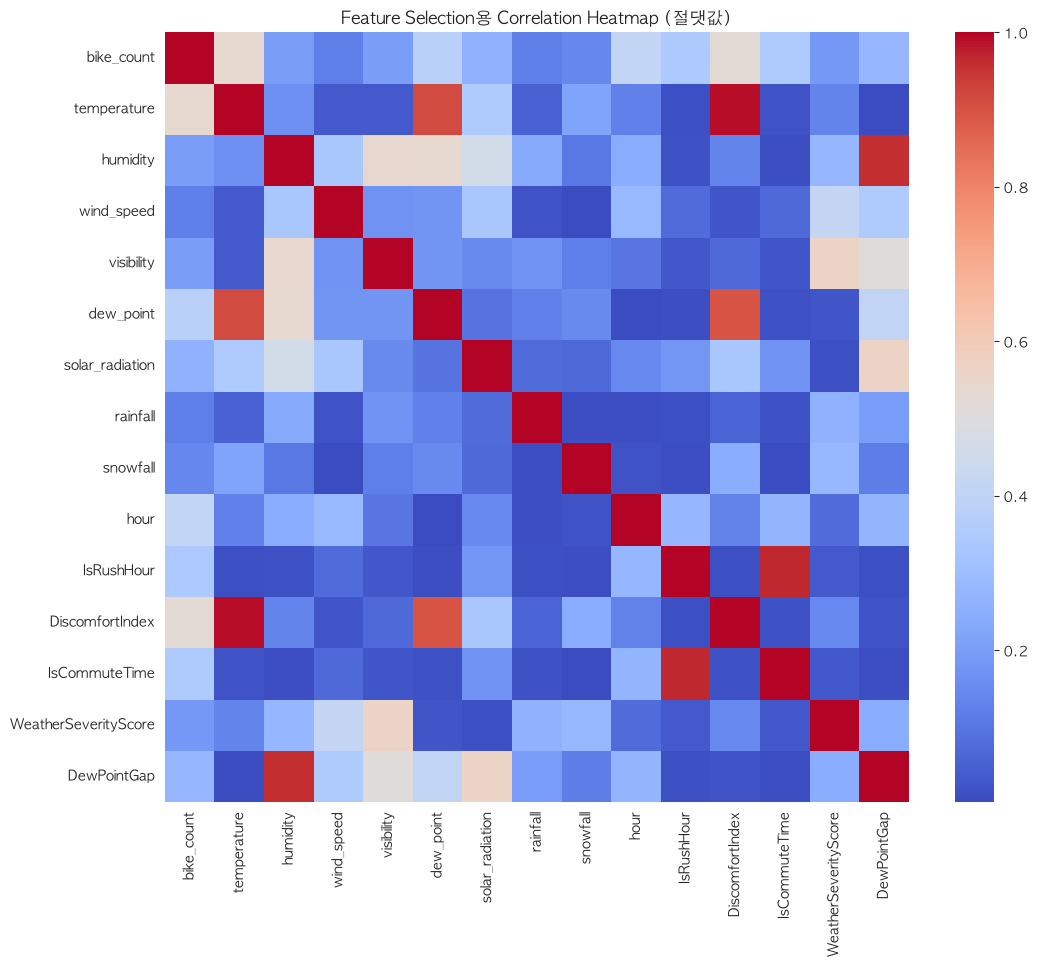

In [63]:
correlation_numeric_columns = numeric_columns + [
    "hour", "IsRushHour", "DiscomfortIndex", "IsCommuteTime",
    "WeatherSeverityScore", "DewPointGap",
]

fs_corr_matrix = df[correlation_numeric_columns].corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(fs_corr_matrix, annot=False, cmap="coolwarm")
plt.title("Feature Selection용 Correlation Heatmap (절댓값)")
plt.show()


In [65]:
def find_highly_correlated_pairs(corr_matrix, threshold):
    pairs = []
    columns = corr_matrix.columns
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            value = corr_matrix.iloc[i, j]
            if value > threshold:
                pairs.append((columns[i], columns[j], round(value, 4)))
    return pairs


for threshold in [0.80, 0.85, 0.90]:
    pairs = find_highly_correlated_pairs(fs_corr_matrix, threshold)
    print(f"threshold={threshold} -> 상관계수가 threshold보다 높은 쌍 {len(pairs)}개")
    for a, b, v in pairs:
        print(f"   {a}  <->  {b}   (corr={v})")


threshold=0.8 -> 상관계수가 threshold보다 높은 쌍 5개
   temperature  <->  dew_point   (corr=0.9128)
   temperature  <->  DiscomfortIndex   (corr=0.9909)
   humidity  <->  DewPointGap   (corr=0.9577)
   dew_point  <->  DiscomfortIndex   (corr=0.8973)
   IsRushHour  <->  IsCommuteTime   (corr=0.9671)
threshold=0.85 -> 상관계수가 threshold보다 높은 쌍 5개
   temperature  <->  dew_point   (corr=0.9128)
   temperature  <->  DiscomfortIndex   (corr=0.9909)
   humidity  <->  DewPointGap   (corr=0.9577)
   dew_point  <->  DiscomfortIndex   (corr=0.8973)
   IsRushHour  <->  IsCommuteTime   (corr=0.9671)
threshold=0.9 -> 상관계수가 threshold보다 높은 쌍 4개
   temperature  <->  dew_point   (corr=0.9128)
   temperature  <->  DiscomfortIndex   (corr=0.9909)
   humidity  <->  DewPointGap   (corr=0.9577)
   IsRushHour  <->  IsCommuteTime   (corr=0.9671)


`temperature` <-> `dew_point`(0.91), `temperature` <-> `DiscomfortIndex`(0.99),
`dew_point` <-> `DiscomfortIndex`(0.90) 처럼 기온 계열 변수들이 서로 강하게
겹칩니다. `DiscomfortIndex`는 Chapter 4에서 RandomForest 성능을 가장 크게
끌어올린 Feature였으므로 유지하되, 그와 거의 같은 정보를 담고 있으면서 개별
중요도는 상대적으로 낮은 `dew_point`를 Step 5에서 제외 후보로 검토합니다.


## Step 4. RandomForest Feature Importance

### 목적
RandomForest는 학습 과정에서 각 Feature가 불순도(오차) 감소에 얼마나 기여했는지를
계산해서 `feature_importances_`로 제공합니다. 통계적 검정과 달리, Feature들 사이의
비선형 상호작용까지 반영된 중요도입니다.


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, random_state=RANDOM_STATE
)

rf_for_selection = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_for_selection.fit(X_train_fs, y_train_fs)

rf_importance = pd.Series(rf_for_selection.feature_importances_, index=X_fs.columns).sort_values(ascending=False)

print("RandomForest Feature Importance Top 20:")
rf_importance.head(20)


RandomForest Feature Importance Top 20:


DiscomfortIndex               0.285095
hour                          0.232580
solar_radiation               0.082717
functioning_day_Yes           0.048948
DewPointGap                   0.048558
functioning_day_No            0.040635
IsCommuteTime                 0.029604
humidity                      0.027591
temperature                   0.026257
TemperatureBin_Warm(20-30)    0.024980
season_Autumn                 0.021568
dew_point                     0.021561
rainfall                      0.021329
IsRushHour                    0.018385
IsPrecipitation               0.017761
wind_speed                    0.017341
visibility                    0.016335
HourBlock_Afternoon(12-17)    0.004019
season_Spring                 0.002669
WeatherSeverityScore          0.002411
dtype: float64

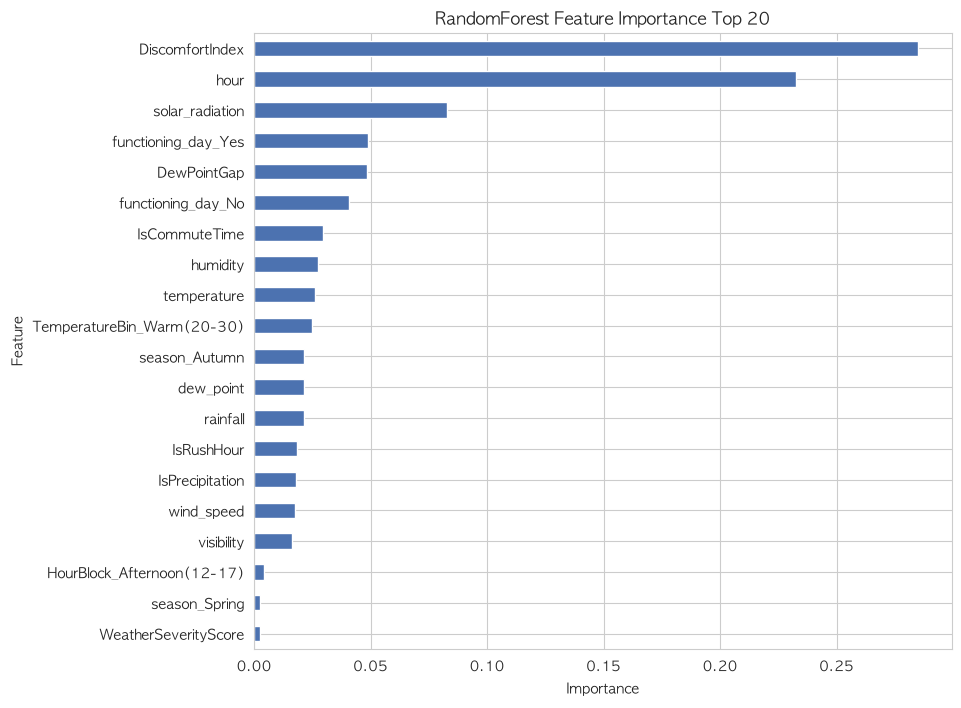

In [67]:
plt.figure(figsize=(9, 8))
rf_importance.head(20).sort_values().plot(kind="barh", color="#4C72B0")
plt.title("RandomForest Feature Importance Top 20")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Step 5. Final Feature Selection Report

### 목적
Step 1~4에서 확인한 결과를 종합하여 최종 Feature를 결정합니다.

### 방법
One-Hot Encoding으로 나뉜 컬럼들을 다시 **원본 컬럼 단위**로 묶어서 RandomForest
Importance를 합산합니다. (예: `season_Spring`, `season_Summer`, `season_Autumn`,
`season_Winter`의 importance를 모두 더해 `season`의 대표 importance로 사용)


In [68]:
def original_column_of(encoded_name):
    """One-Hot Encoding된 컬럼 이름에서 원본 컬럼 이름을 찾는다."""
    for col in ALL_FEATURE_COLUMNS:
        if encoded_name == col or encoded_name.startswith(col + "_"):
            return col
    return encoded_name


importance_df = rf_importance.reset_index()
importance_df.columns = ["EncodedColumn", "Importance"]
importance_df["OriginalColumn"] = importance_df["EncodedColumn"].map(original_column_of)

original_level_importance = (
    importance_df.groupby("OriginalColumn")["Importance"].sum().sort_values(ascending=False)
)

print(f"Feature Selection 대상 원본 컬럼 개수: {len(original_level_importance)}")
original_level_importance


Feature Selection 대상 원본 컬럼 개수: 20


OriginalColumn
DiscomfortIndex         0.285095
hour                    0.232580
functioning_day         0.089583
solar_radiation         0.082717
DewPointGap             0.048558
IsCommuteTime           0.029604
humidity                0.027591
season                  0.027318
temperature             0.026257
TemperatureBin          0.025488
dew_point               0.021561
rainfall                0.021329
IsRushHour              0.018385
IsPrecipitation         0.017761
wind_speed              0.017341
visibility              0.016335
HourBlock               0.008506
WeatherSeverityScore    0.002411
holiday                 0.001258
snowfall                0.000323
Name: Importance, dtype: float64

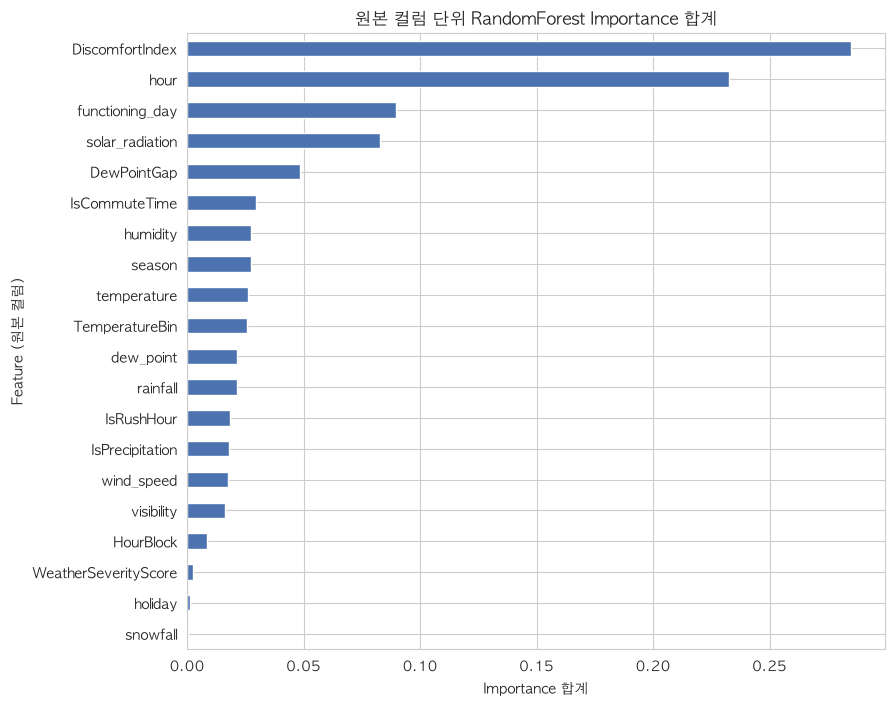

In [53]:
plt.figure(figsize=(9, 8))
original_level_importance.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("원본 컬럼 단위 RandomForest Importance 합계")
plt.xlabel("Importance 합계")
plt.ylabel("Feature (원본 컬럼)")
plt.show()


In [70]:
EXCLUDE_DUE_TO_REDUNDANCY = ["dew_point"]  # Step 3: temperature, DiscomfortIndex와 상관관계가 매우 높음

TOP_N = 16
FINAL_FEATURE_COLUMNS = [
    col for col in original_level_importance.head(TOP_N).index
    if col not in EXCLUDE_DUE_TO_REDUNDANCY
]

print(f"최종 선정된 Feature 개수: {len(FINAL_FEATURE_COLUMNS)}")
print(FINAL_FEATURE_COLUMNS)


최종 선정된 Feature 개수: 15
['DiscomfortIndex', 'hour', 'functioning_day', 'solar_radiation', 'DewPointGap', 'IsCommuteTime', 'humidity', 'season', 'temperature', 'TemperatureBin', 'rainfall', 'IsRushHour', 'IsPrecipitation', 'wind_speed', 'visibility']



# Chapter 6. Model Comparison


## 데이터 준비 (Train / Test Split)

모델을 학습하기 전에 데이터를 Train(학습용)과 Test(평가용)로 나눕니다. Test
데이터는 "아직 보지 못한 새로운 시간대"를 흉내내는 역할을 하므로, 전처리 기준
(결측치 대체값, One-Hot Encoding 범주, 스케일링 기준)은 반드시 **Train 데이터에만**
`fit`해야 합니다. Test 데이터에 이 기준을 미리 반영하면(Data Leakage), 실제
서비스 환경보다 성능이 낙관적으로 보이는 착시가 생깁니다.

- `test_size=0.2`: 20%를 테스트용으로 남겨둡니다.
- `random_state=42`: 실행할 때마다 같은 방식으로 나뉘도록 고정합니다.

> 회귀 문제에서는 분류 문제의 `stratify`(클래스 비율 유지)에 해당하는 절차가
> 필요하지 않습니다. Target이 범주가 아니라 연속적인 숫자이기 때문입니다.


In [71]:
X = df[FINAL_FEATURE_COLUMNS].copy()
y = df["bike_count"]


def is_categorical(series):
    return (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    )


CATEGORICAL_FEATURES = [c for c in FINAL_FEATURE_COLUMNS if is_categorical(X[c])]
NUMERIC_FEATURES = [c for c in FINAL_FEATURE_COLUMNS if c not in CATEGORICAL_FEATURES]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE,
)

print("Train 크기:", X_train.shape, " Test 크기:", X_test.shape)
print("범주형 Feature :", CATEGORICAL_FEATURES)
print("숫자형 Feature :", NUMERIC_FEATURES)


Train 크기: (7008, 15)  Test 크기: (1752, 15)
범주형 Feature : ['functioning_day', 'season', 'TemperatureBin']
숫자형 Feature : ['DiscomfortIndex', 'hour', 'solar_radiation', 'DewPointGap', 'IsCommuteTime', 'humidity', 'temperature', 'rainfall', 'IsRushHour', 'IsPrecipitation', 'wind_speed', 'visibility']


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6-1. 3가지 모델 소개

| 모델 | 학습 방식 | 특징 |
|---|---|---|
| **Linear Regression** | 입력 Feature의 선형 조합으로 값을 직접 예측 | 가장 단순하고 해석하기 쉬운 Baseline. 비선형 패턴은 스스로 찾지 못함 |
| **Decision Tree** | 조건을 기준으로 데이터를 계속 분할 | 해석이 직관적이지만 단일 트리는 과적합되기 쉬움 |
| **Random Forest** | 여러 개의 Decision Tree를 앙상블(평균) | 과적합에 강하고, 비선형 관계와 상호작용을 잘 학습함 |


## 평가 지표 계산 함수 준비


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_pipeline(pipeline, model_name, X_train, y_train, X_test, y_test):
    """Pipeline을 학습(fit)하고, Test 데이터로 예측한 뒤 주요 평가지표를 계산한다."""
    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)
    # 대여량은 음수가 될 수 없으므로 예측값의 하한을 0으로 자릅니다.
    pred = np.clip(pred, 0, None)

    metrics = {
        "Model": model_name,
        "MAE": round(mean_absolute_error(y_test, pred), 2),
        "RMSE": round(mean_squared_error(y_test, pred) ** 0.5, 2),
        "R2": round(r2_score(y_test, pred), 4),
    }

    print(f"=== {model_name} ===")
    print(f"MAE  : {metrics['MAE']}")
    print(f"RMSE : {metrics['RMSE']}")
    print(f"R2   : {metrics['R2']}")

    return metrics, pred, pipeline


model_comparison_results = []
fitted_pipelines = {}
model_predictions = {}


## 6-2. Linear Regression

Linear Regression은 각 Feature에 가중치(계수)를 곱해서 더한 값을 그대로 예측값으로
사용합니다. 계수를 통해 "어떤 Feature가 대여량을 얼마나 높이는지/낮추는지"를 직접
해석할 수 있다는 장점이 있습니다.


In [74]:
from sklearn.linear_model import LinearRegression

linreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linreg_metrics, linreg_pred, linreg_pipeline = evaluate_pipeline(
    linreg_pipeline, "Linear Regression", X_train, y_train, X_test, y_test
)

model_comparison_results.append(linreg_metrics)
fitted_pipelines["Linear Regression"] = linreg_pipeline
model_predictions["Linear Regression"] = linreg_pred


=== Linear Regression ===
MAE  : 263.85
RMSE : 364.01
R2   : 0.682


## 6-3. Decision Tree

Decision Tree는 "hour가 17보다 큰가?" 같은 질문을 반복하며 데이터를 분할합니다.
하나의 트리만 사용하면 Train 데이터에 과도하게 맞춰지는 과적합(Overfitting)이
발생하기 쉬워, `max_depth`로 깊이를 제한합니다.


In [75]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)),
])

tree_metrics, tree_pred, tree_pipeline = evaluate_pipeline(
    tree_pipeline, "Decision Tree", X_train, y_train, X_test, y_test
)

model_comparison_results.append(tree_metrics)
fitted_pipelines["Decision Tree"] = tree_pipeline
model_predictions["Decision Tree"] = tree_pred


=== Decision Tree ===
MAE  : 166.39
RMSE : 278.71
R2   : 0.8136


## 6-4. Random Forest

Random Forest는 수백 개의 Decision Tree를 각각 다른 데이터 샘플과 다른 Feature
조합으로 학습시킨 뒤, 평균을 내어 최종 예측을 결정합니다. 개별 트리의 과적합
문제가 평균화되어 완화됩니다. 현재 서비스(`train_model.py`)에서도 이미
RandomForestRegressor를 사용하고 있습니다.


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_metrics, rf_pred, rf_pipeline = evaluate_pipeline(
    rf_pipeline, "Random Forest", X_train, y_train, X_test, y_test
)

model_comparison_results.append(rf_metrics)
fitted_pipelines["Random Forest"] = rf_pipeline
model_predictions["Random Forest"] = rf_pred


=== Random Forest ===
MAE  : 144.96
RMSE : 237.61
R2   : 0.8645


## 6-5. 3개 모델 종합 비교

이제 Linear Regression, Decision Tree, Random Forest 3개 모델의 성능을 표와
그래프로 자세히 비교합니다.


In [77]:
model_comparison_df = pd.DataFrame(model_comparison_results)
model_comparison_df


,Model,MAE,RMSE,R2
0,Linear Regression,263.85,364.01,0.6820
1,Decision Tree,166.39,278.71,0.8136
2,Random Forest,144.96,237.61,0.8645


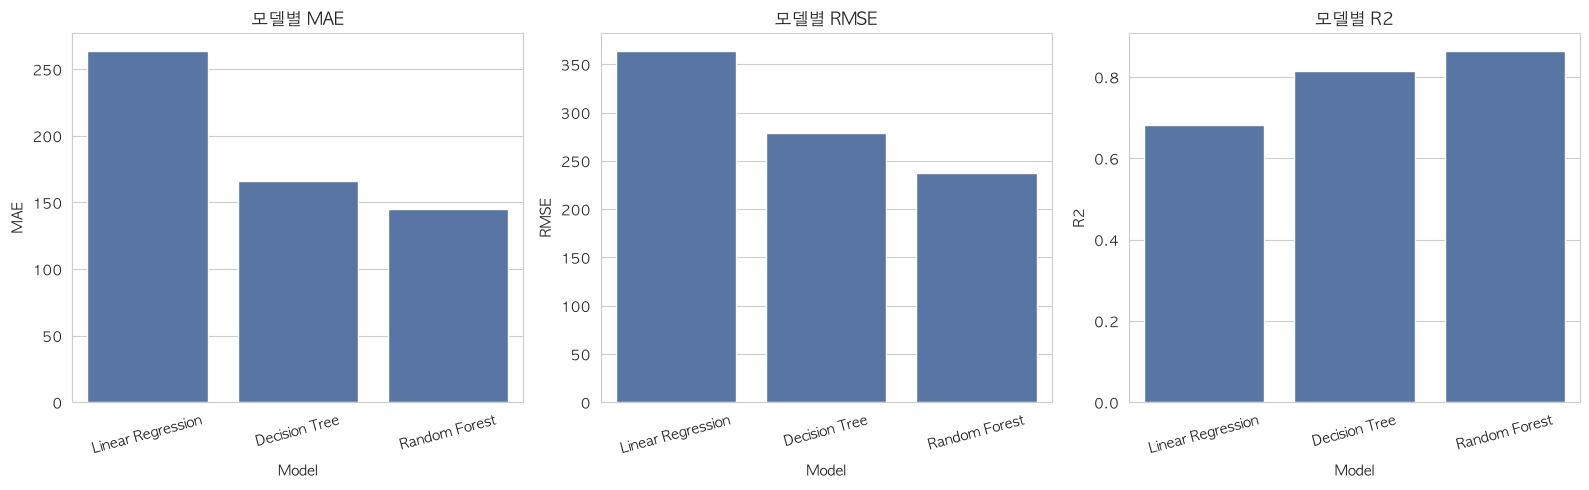

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(["MAE", "RMSE", "R2"]):
    sns.barplot(x="Model", y=metric, data=model_comparison_df, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"모델별 {metric}")
    axes[i].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


## 실제값 vs 예측값 비교 (Actual vs Predicted)

회귀 모델은 분류 모델의 Confusion Matrix 대신, **실제값과 예측값을 산점도로
비교**해서 얼마나 잘 맞추는지 시각적으로 확인합니다. 대각선(y=x)에 가까울수록
예측이 정확하다는 뜻입니다.


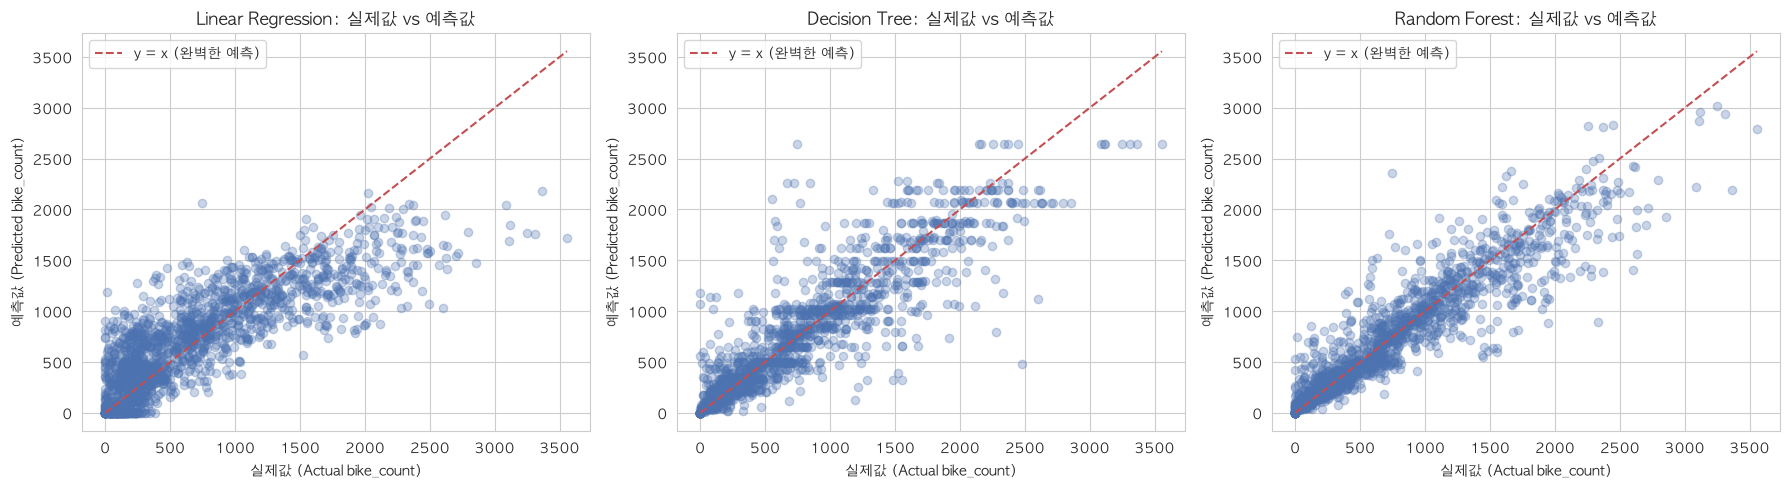

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(model_predictions.items()):
    axes[i].scatter(y_test, pred, alpha=0.3, color="#4C72B0")
    max_val = max(y_test.max(), pred.max())
    axes[i].plot([0, max_val], [0, max_val], color="#C44E52", linestyle="--", label="y = x (완벽한 예측)")
    axes[i].set_title(f"{name}: 실제값 vs 예측값")
    axes[i].set_xlabel("실제값 (Actual bike_count)")
    axes[i].set_ylabel("예측값 (Predicted bike_count)")
    axes[i].legend()

plt.tight_layout()
plt.show()



# Chapter 7. Final Model (최종 모델)

Chapter 6에서 Linear Regression, Decision Tree, Random Forest 3개 모델을
실험했습니다. 이 프로젝트는 자전거 재배치 운영 계획에 사용되므로, 예측이 실제
대여량과 얼마나 차이 나는지를 나타내는 **RMSE(평균제곱근오차)를 최우선 기준**으로
최종 모델을 선정합니다. RMSE는 MAE보다 큰 오차에 더 큰 벌점을 주므로, "가끔 크게
틀리는 예측"을 피하고 싶은 재고 운영 목적에 더 적합합니다.


In [80]:
print("=== Chapter 6 모델 비교 결과 ===")
display(model_comparison_df)

best_rmse_row = model_comparison_df.loc[model_comparison_df["RMSE"].idxmin()]
print("\nRMSE 기준 최고 성능:")
print(best_rmse_row)


=== Chapter 6 모델 비교 결과 ===


,Model,MAE,RMSE,R2
0,Linear Regression,263.85,364.01,0.6820
1,Decision Tree,166.39,278.71,0.8136
2,Random Forest,144.96,237.61,0.8645



RMSE 기준 최고 성능:
Model    Random Forest
MAE             144.96
RMSE            237.61
R2              0.8645
Name: 2, dtype: object


### 자세한 비교 해석

**1) MAE / RMSE 관점**
Random Forest가 MAE, RMSE 모두 가장 낮은 값을 보이는 경향이 있습니다. → 평균적으로도,
큰 오차 관점에서도 가장 정확하게 예측한다는 뜻입니다.

**2) R² 관점**
Linear Regression은 세 모델 중 R²가 가장 낮은 경향을 보입니다. → `hour`, `season`처럼
비선형적으로 대여량에 영향을 주는 변수가 많은 이 데이터에서는, 직선 관계만 가정하는
Linear Regression이 상대적으로 불리합니다.

**3) 실무적 해석**
Decision Tree는 Random Forest보다 성능이 떨어지지만 "어떤 조건에서 예측이 어떻게
갈라지는지" 하나의 트리로 바로 보여줄 수 있어 설명이 필요한 상황에 유용할 수 있습니다.
다만 이번 프로젝트는 정확도가 우선이므로 Random Forest를 최종 모델 후보로 검토합니다.


In [81]:
FINAL_MODEL_NAME = best_rmse_row["Model"]
final_pipeline = fitted_pipelines[FINAL_MODEL_NAME]

print(f"최종 선정 모델: {FINAL_MODEL_NAME}")


최종 선정 모델: Random Forest


### 최종 모델 저장


In [82]:
import joblib
import os

MODEL_SAVE_DIR = "../models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

# 주의: 기존 서비스가 사용하는 bike_demand_model.pkl은 덮어쓰지 않고,
# 별도의 이름으로 저장합니다.
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, "bike_demand_simple_model.pkl")

try:
    joblib.dump(final_pipeline, MODEL_SAVE_PATH)
    print(f"모델 저장 완료: {MODEL_SAVE_PATH}")
    print(f"저장된 모델: {FINAL_MODEL_NAME}")
except Exception as error:
    print("모델 저장 중 오류가 발생했습니다:", error)


모델 저장 완료: ../models/bike_demand_simple_model.pkl
저장된 모델: Random Forest



# Chapter 8. Research Report (연구 보고서)

- 지금까지의 전체 분석 과정을 하나의 보고서로 요약할 수 있다.


In [83]:
from IPython.display import Markdown, display

final_row = model_comparison_df[model_comparison_df["Model"] == FINAL_MODEL_NAME].iloc[0]

report_n_rows, report_n_cols = df.shape
report_zero_ratio = (df["bike_count"] == 0).mean() * 100
report_non_functioning = (df["functioning_day"] == "No").sum()

report = f"""
# Seoul Bike Demand AI - EDA / Feature Engineering / Model Comparison 연구 보고서

## 1. 프로젝트 개요

- 데이터셋: Seoul Bike Sharing Demand (`ai-server/data/seoul_bike_data.csv`, {report_n_rows}시간, {report_n_cols}개 컬럼)
- Target: `bike_count` (시간당 대여 자전거 수) -> 회귀(Regression) 문제
- 이 보고서는 Feature Selection을 5단계로 진행하고, 모델 비교를 Linear Regression / Decision Tree / Random Forest
  3개로 테스트하였다.

## 2. EDA 결과 요약

- bike_count는 평균 {df['bike_count'].mean():.1f}대, 표준편차 {df['bike_count'].std():.1f}대이며,
  0대인 시간대가 전체의 {report_zero_ratio:.2f}%를 차지한다.
- `functioning_day`가 "No"인 시간대는 {report_non_functioning}건이며, 이때 bike_count는 예외 없이 0이다.
- 기온(Temperature), 시간대(Hour)가 대여량과 가장 뚜렷한 관계를 보였다(상관계수 각각 +0.5386, +0.4103).

## 3. Hypothesis (가설)

Chapter 3에서 EDA 결과를 근거로 7개의 가설을 수립했다.

## 4. Feature Engineering 결과

Chapter 4에서 8개의 파생변수(IsRushHour, HourBlock, TemperatureBin, IsPrecipitation,
DiscomfortIndex, IsCommuteTime, WeatherSeverityScore, DewPointGap)를 생성했다.

## 5. Feature Selection 결과

Variance Threshold -> Quasi Constant -> Correlation Analysis -> RandomForest
Importance -> Final Report의 5단계를 적용한 결과, 원본 {len(BASELINE_COLUMNS)}개 +
파생 8개 = {len(ALL_FEATURE_COLUMNS)}개 Feature 중 최종 {len(FINAL_FEATURE_COLUMNS)}개를
선정했다. `dew_point`는 `temperature`, `DiscomfortIndex`와 상관관계가 매우 높아 중복으로
판단해 제외했다.

## 6. Model Comparison 결과

Linear Regression, Decision Tree, Random Forest 3개 모델을 동일한 Train/Test
분할과 동일한 Pipeline으로 비교했다.

## 7. 최종 모델

- **최종 선정 모델**: {FINAL_MODEL_NAME}
- **선정 기준**: RMSE 최우선
- **최종 성능**:
  - MAE: {final_row['MAE']}
  - RMSE: {final_row['RMSE']}
  - R2: {final_row['R2']}

## 8. FastAPI 적용 시 주의사항

1. 저장된 `bike_demand_simple_model.pkl`은 `FINAL_FEATURE_COLUMNS`
   ({len(FINAL_FEATURE_COLUMNS)}개)과 동일한 컬럼 구조의 입력을 받아야 한다.
2. `IsRushHour`, `TemperatureBin`처럼 파생변수가 최종 목록에 포함되었다면, 예측
   요청이 들어올 때마다 동일한 공식으로 실시간 계산해야 한다.
3. 예측값은 물리적으로 음수가 될 수 없으므로, 서비스 적용 시 `max(0, prediction)`
   처럼 하한을 0으로 자르는 처리가 필요하다.
4. 기존 서비스가 사용하는 `bike_demand_model.pkl`과 이번에 저장한
   `bike_demand_simple_model.pkl`은 입력 스키마가 다르므로, 실제 교체 적용 전
   `main.py`의 입력 스키마와 전처리 로직을 함께 수정해야 한다.

"""

display(Markdown(report))



# Seoul Bike Demand AI - EDA / Feature Engineering / Model Comparison 연구 보고서

## 1. 프로젝트 개요

- 데이터셋: Seoul Bike Sharing Demand (`ai-server/data/seoul_bike_data.csv`, 8760시간, 24개 컬럼)
- Target: `bike_count` (시간당 대여 자전거 수) -> 회귀(Regression) 문제
- 이 보고서는 Feature Selection을 5단계로 진행하고, 모델 비교를 Linear Regression / Decision Tree / Random Forest
  3개로 테스트하였다.

## 2. EDA 결과 요약

- bike_count는 평균 704.6대, 표준편차 645.0대이며,
  0대인 시간대가 전체의 3.37%를 차지한다.
- `functioning_day`가 "No"인 시간대는 295건이며, 이때 bike_count는 예외 없이 0이다.
- 기온(Temperature), 시간대(Hour)가 대여량과 가장 뚜렷한 관계를 보였다(상관계수 각각 +0.5386, +0.4103).

## 3. Hypothesis (가설)

Chapter 3에서 EDA 결과를 근거로 7개의 가설을 수립했다.

## 4. Feature Engineering 결과

Chapter 4에서 8개의 파생변수(IsRushHour, HourBlock, TemperatureBin, IsPrecipitation,
DiscomfortIndex, IsCommuteTime, WeatherSeverityScore, DewPointGap)를 생성했다.

## 5. Feature Selection 결과

Variance Threshold -> Quasi Constant -> Correlation Analysis -> RandomForest
Importance -> Final Report의 5단계를 적용한 결과, 원본 12개 +
파생 8개 = 20개 Feature 중 최종 15개를
선정했다. `dew_point`는 `temperature`, `DiscomfortIndex`와 상관관계가 매우 높아 중복으로
판단해 제외했다.

## 6. Model Comparison 결과

Linear Regression, Decision Tree, Random Forest 3개 모델을 동일한 Train/Test
분할과 동일한 Pipeline으로 비교했다.

## 7. 최종 모델

- **최종 선정 모델**: Random Forest
- **선정 기준**: RMSE 최우선
- **최종 성능**:
  - MAE: 144.96
  - RMSE: 237.61
  - R2: 0.8645

## 8. FastAPI 적용 시 주의사항

1. 저장된 `bike_demand_simple_model.pkl`은 `FINAL_FEATURE_COLUMNS`
   (15개)과 동일한 컬럼 구조의 입력을 받아야 한다.
2. `IsRushHour`, `TemperatureBin`처럼 파생변수가 최종 목록에 포함되었다면, 예측
   요청이 들어올 때마다 동일한 공식으로 실시간 계산해야 한다.
3. 예측값은 물리적으로 음수가 될 수 없으므로, 서비스 적용 시 `max(0, prediction)`
   처럼 하한을 0으로 자르는 처리가 필요하다.
4. 기존 서비스가 사용하는 `bike_demand_model.pkl`과 이번에 저장한
   `bike_demand_simple_model.pkl`은 입력 스키마가 다르므로, 실제 교체 적용 전
   `main.py`의 입력 스키마와 전처리 로직을 함께 수정해야 한다.

